# Análise de Ações de Big Techs: Risco, Regimes e Previsibilidade

**Objetivo:** Investigar o comportamento de preços, risco e estrutura de dependência de grandes empresas de tecnologia, partindo de análises exploratórias até modelagem de regimes e exercícios de previsão.

**Empresas:** AAPL, MSFT, GOOG, AMZN, META, NVDA, TSLA, AMD

**Período:** Janeiro de 2015 até o presente

**Dados:** Yahoo Finance (yfinance)

---

## 1. Coleta e Preparação dos Dados

Utilizamos preços de fechamento ajustados (*Adjusted Close*), que incorporam dividendos e splits, garantindo consistência na série temporal.

Os retornos são calculados em escala logarítmica: $r_t = \ln(P_t / P_{t-1})$. Retornos log têm propriedades desejáveis para análise financeira — são aditivos no tempo e apresentam melhor comportamento estatístico em relação a retornos simples.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import warnings
warnings.filterwarnings('ignore')

# Configuração visual
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de cores — escolhidas para máximo contraste entre si
TICKERS = ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'NVDA', 'TSLA', 'AMD']
COLORS = {
    'AAPL': '#1A1A1A',
    'MSFT': '#0078D4',
    'GOOG': '#0F9D58',
    'AMZN': '#FF9900',
    'META': '#8B5CF6',
    'NVDA': '#06B6D4',
    'TSLA': '#DC2626',
    'AMD': '#E91E8C'  
}

In [2]:
import yfinance as yf

# Download dos dados
data = yf.download(TICKERS, start='2015-01-01', auto_adjust=True)
prices = data['Close'][TICKERS]
prices.dropna(inplace=True)

# Retornos logarítmicos
log_returns = np.log(prices / prices.shift(1)).dropna()

# Volume (para análise posterior)
volume = data['Volume'][TICKERS]

print(f"Período: {prices.index[0].strftime('%Y-%m-%d')} a {prices.index[-1].strftime('%Y-%m-%d')}")
print(f"Dias úteis: {len(prices)}")
print(f"\nPrimeiras linhas dos preços ajustados:")
prices.head()

[*********************100%***********************]  8 of 8 completed

Período: 2015-01-02 a 2026-04-21
Dias úteis: 2841

Primeiras linhas dos preços ajustados:


Ticker,AAPL,MSFT,GOOG,AMZN,META,NVDA,TSLA,AMD
Date,,,,,,,,
2015-01-02,24.214895,39.767689,25.955561,15.4260,77.839172,0.482985,14.620667,2.67
2015-01-05,23.532719,39.402008,25.414501,15.1095,76.588974,0.474828,14.006000,2.66
2015-01-06,23.534937,38.823673,24.825466,14.7645,75.557068,0.460431,14.085333,2.63
2015-01-07,23.864950,39.316933,24.782936,14.9210,75.557068,0.459232,14.063333,2.58
2015-01-08,24.781887,40.473587,24.861076,15.0230,77.571259,0.476507,14.041333,2.61


In [3]:
# Estatísticas descritivas dos retornos log
desc = log_returns.describe().T
desc['skewness'] = log_returns.skew()
desc['kurtosis'] = log_returns.kurtosis()  # excess kurtosis (normal = 0)
desc[['mean', 'std', 'min', 'max', 'skewness', 'kurtosis']]

,mean,std,min,max,skewness,kurtosis
Ticker,,,,,,
AAPL,0.000850,0.018089,-0.137708,0.142617,-0.089236,6.309559
MSFT,0.000833,0.017045,-0.159453,0.132929,-0.169765,8.181051
GOOG,0.000902,0.018071,-0.117667,0.148872,0.066241,5.803099
AMZN,0.000985,0.020658,-0.151398,0.132178,0.163398,5.666567
META,0.000761,0.023891,-0.306390,0.209307,-1.064149,25.144289
NVDA,0.002126,0.030268,-0.207712,0.260876,0.137139,6.960654
TSLA,0.001159,0.036014,-0.236518,0.204491,-0.047907,4.396155
AMD,0.001640,0.036511,-0.277456,0.420617,0.515504,9.903928


A curtose (medida que caracteriza o achatamento da curva de distribuição de probabilidade) em excesso (kurtosis > 0) já indica que as distribuições de retorno têm caudas mais pesadas do que a distribuição normal, um tema que será explorado na próxima seção


---

## 2. Análise Exploratória

### 2.1 Comportamento dos preços

Visualização dos preços absolutos ao longo do período. Note que as escalas são muito diferentes entre as ações, uma ação da META, por exemplo, é muito mais cara do que uma ação da AMD, no entanto isso não permite comparar o desempenho das duas empresas em um período de tempo. Esse problema é resolvido na próxima seção usando o preço normalizado.

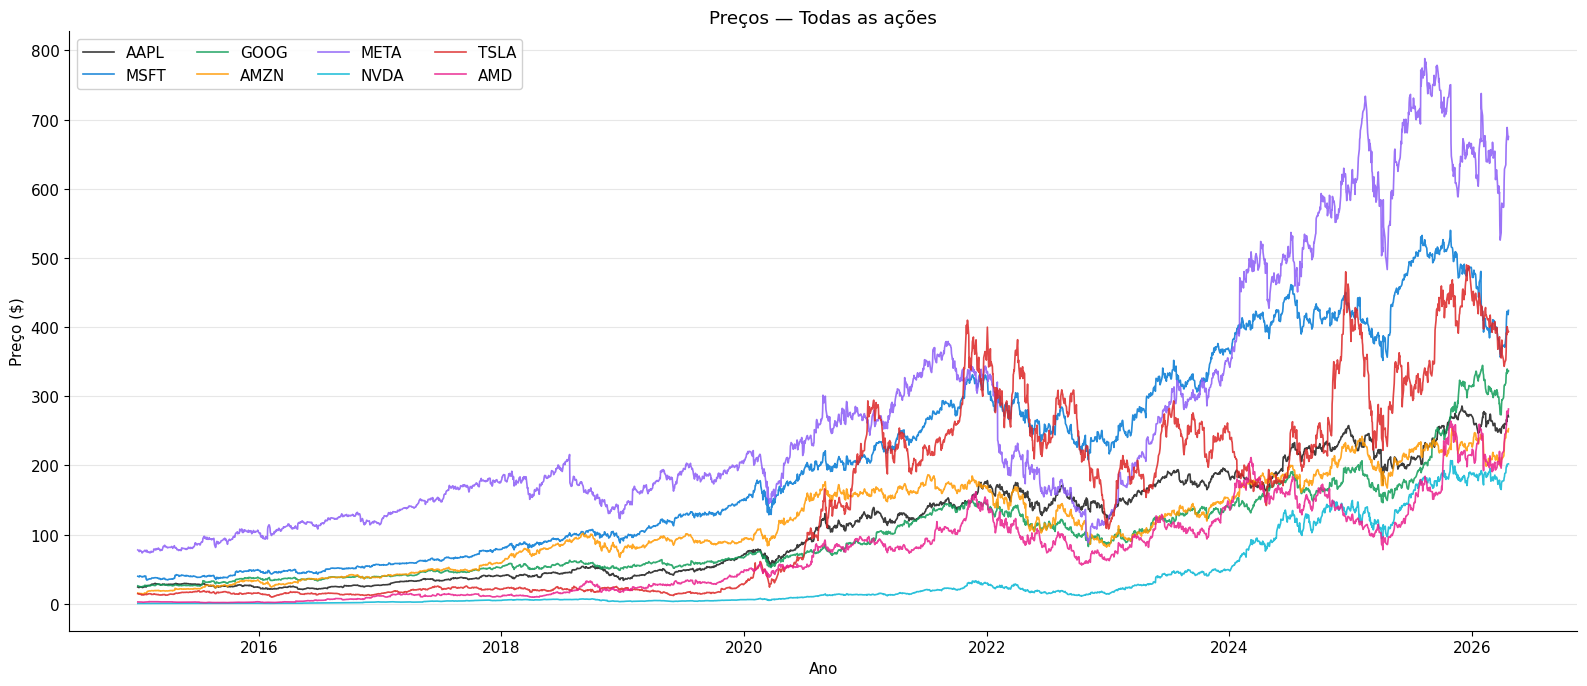

In [ ]:
fig, ax = plt.subplots(figsize=(16, 7))

for ticker in TICKERS:
    ax.plot(prices.index, prices[ticker], label=ticker,
            color=COLORS[ticker], linewidth=1.2, alpha=0.85)
ax.set_ylabel('Preço ($)')
ax.set_xlabel('Ano')
plt.title('Preços — Todas as ações')
plt.legend(loc='upper left', framealpha=0.9, ncol=4)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.2 Performance relativa (preços normalizados, base 100)

Normalizar os preços a uma base comum permite comparar o crescimento relativo de cada ação ao longo do tempo, independente do nível de preço absoluto. Base 100 significa que todas partem do mesmo ponto — 200 indica que dobrou, 1000 que multiplicou por 10.

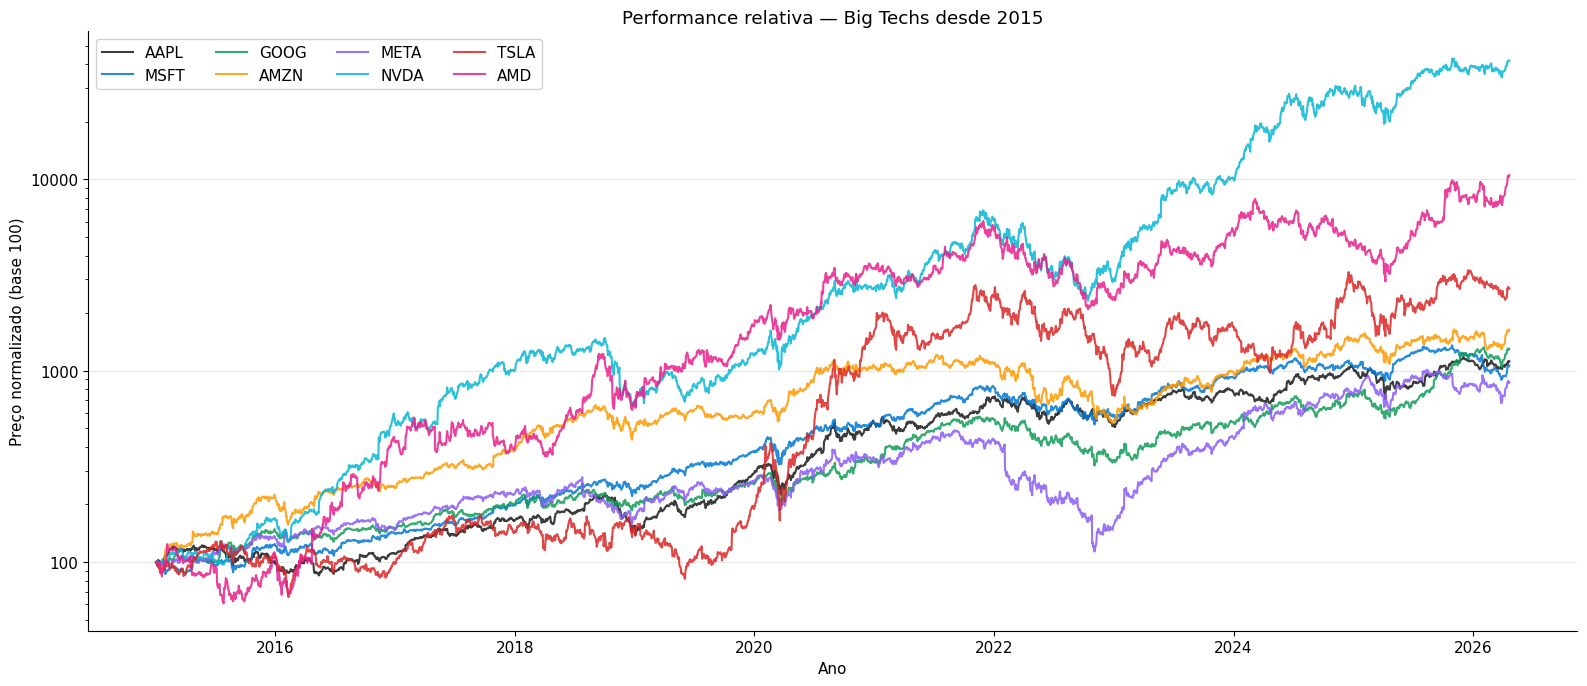

In [60]:
# Preços normalizados a base 100
normalized = (prices / prices.iloc[0]) * 100

fig, ax = plt.subplots(figsize=(16, 7))
for ticker in TICKERS:
    ax.plot(normalized.index, normalized[ticker], label=ticker,
            color=COLORS[ticker], linewidth=1.5, alpha=0.85)

ax.set_ylabel('Preço normalizado (base 100)')
ax.set_xlabel('Ano')
ax.set_title('Performance relativa — Big Techs desde 2015')
ax.legend(loc='upper left', framealpha=0.9, ncol=4)
ax.set_yscale('log')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}'))
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

Note que, no gráfico acima, a história é bem diferente do que foi apresentada pelo preço das ações, NVDA e AMD, duas das ações mais baratas, foram as que tiveram o melhor desempenho no período de 2015 até Abril de 2026.

### 2.3 Retorno acumulado

O retorno acumulado mostra quanto um investimento inicial rendeu ao longo do período. A Nvidia e AMD acumularam um retorno tão superior às demais que comprime todas as outras ações na base do gráfico em escala linear, por isso são apresentados dois gráficos separados, um com NVDA e AMD e outro sem essas duas empresas.

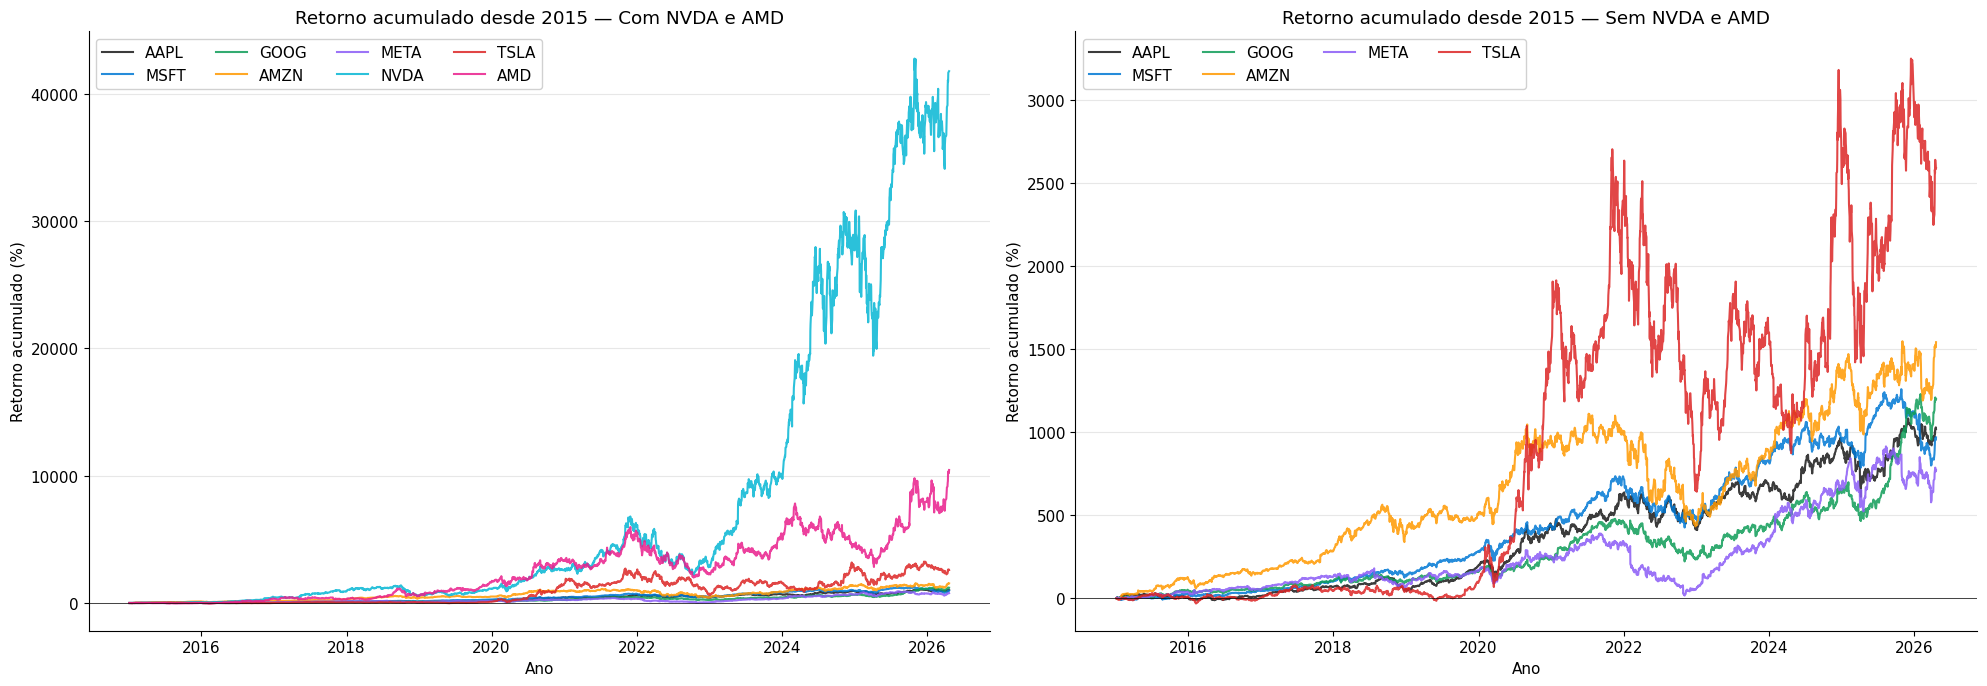

In [62]:
cumulative = (np.exp(log_returns.cumsum()) - 1) * 100

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Gráfico 1: Com NVDA e AMD
ax = axes[0]
for ticker in TICKERS:
    ax.plot(cumulative.index, cumulative[ticker],
            label=ticker, color=COLORS[ticker], linewidth=1.5, alpha=0.85)
ax.set_ylabel('Retorno acumulado (%)')
ax.set_xlabel('Ano')
ax.set_title('Retorno acumulado desde 2015 — Com NVDA e AMD')
ax.legend(loc='upper left', framealpha=0.9, ncol=4)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

# Gráfico 2: Sem NVDA e AMD
ax = axes[1]
for ticker in [t for t in ['AAPL', 'MSFT', 'GOOG', 'AMZN', 'META', 'TSLA']]:
    ax.plot(cumulative.index, cumulative[ticker],
            label=ticker, color=COLORS[ticker], linewidth=1.5, alpha=0.85)
ax.set_ylabel('Retorno acumulado (%)')
ax.set_xlabel('Ano')
ax.set_title('Retorno acumulado desde 2015 — Sem NVDA e AMD')
ax.legend(loc='upper left', framealpha=0.9, ncol=4)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.4 Retornos diários

Os retornos diários revelam o comportamento da ação no tempo. O padrão visual é importante: os retornos parecem aleatórios (sem tendência visível na direção), mas o **tamanho** das oscilações não é aleatório — existem períodos onde as oscilações são pequenas (gráfico "apertado" perto do zero) intercalados com períodos de oscilações enormes (spikes). Esses períodos vêm em blocos: dias de alta volatilidade tendem a ser seguidos por outros dias de alta volatilidade. 

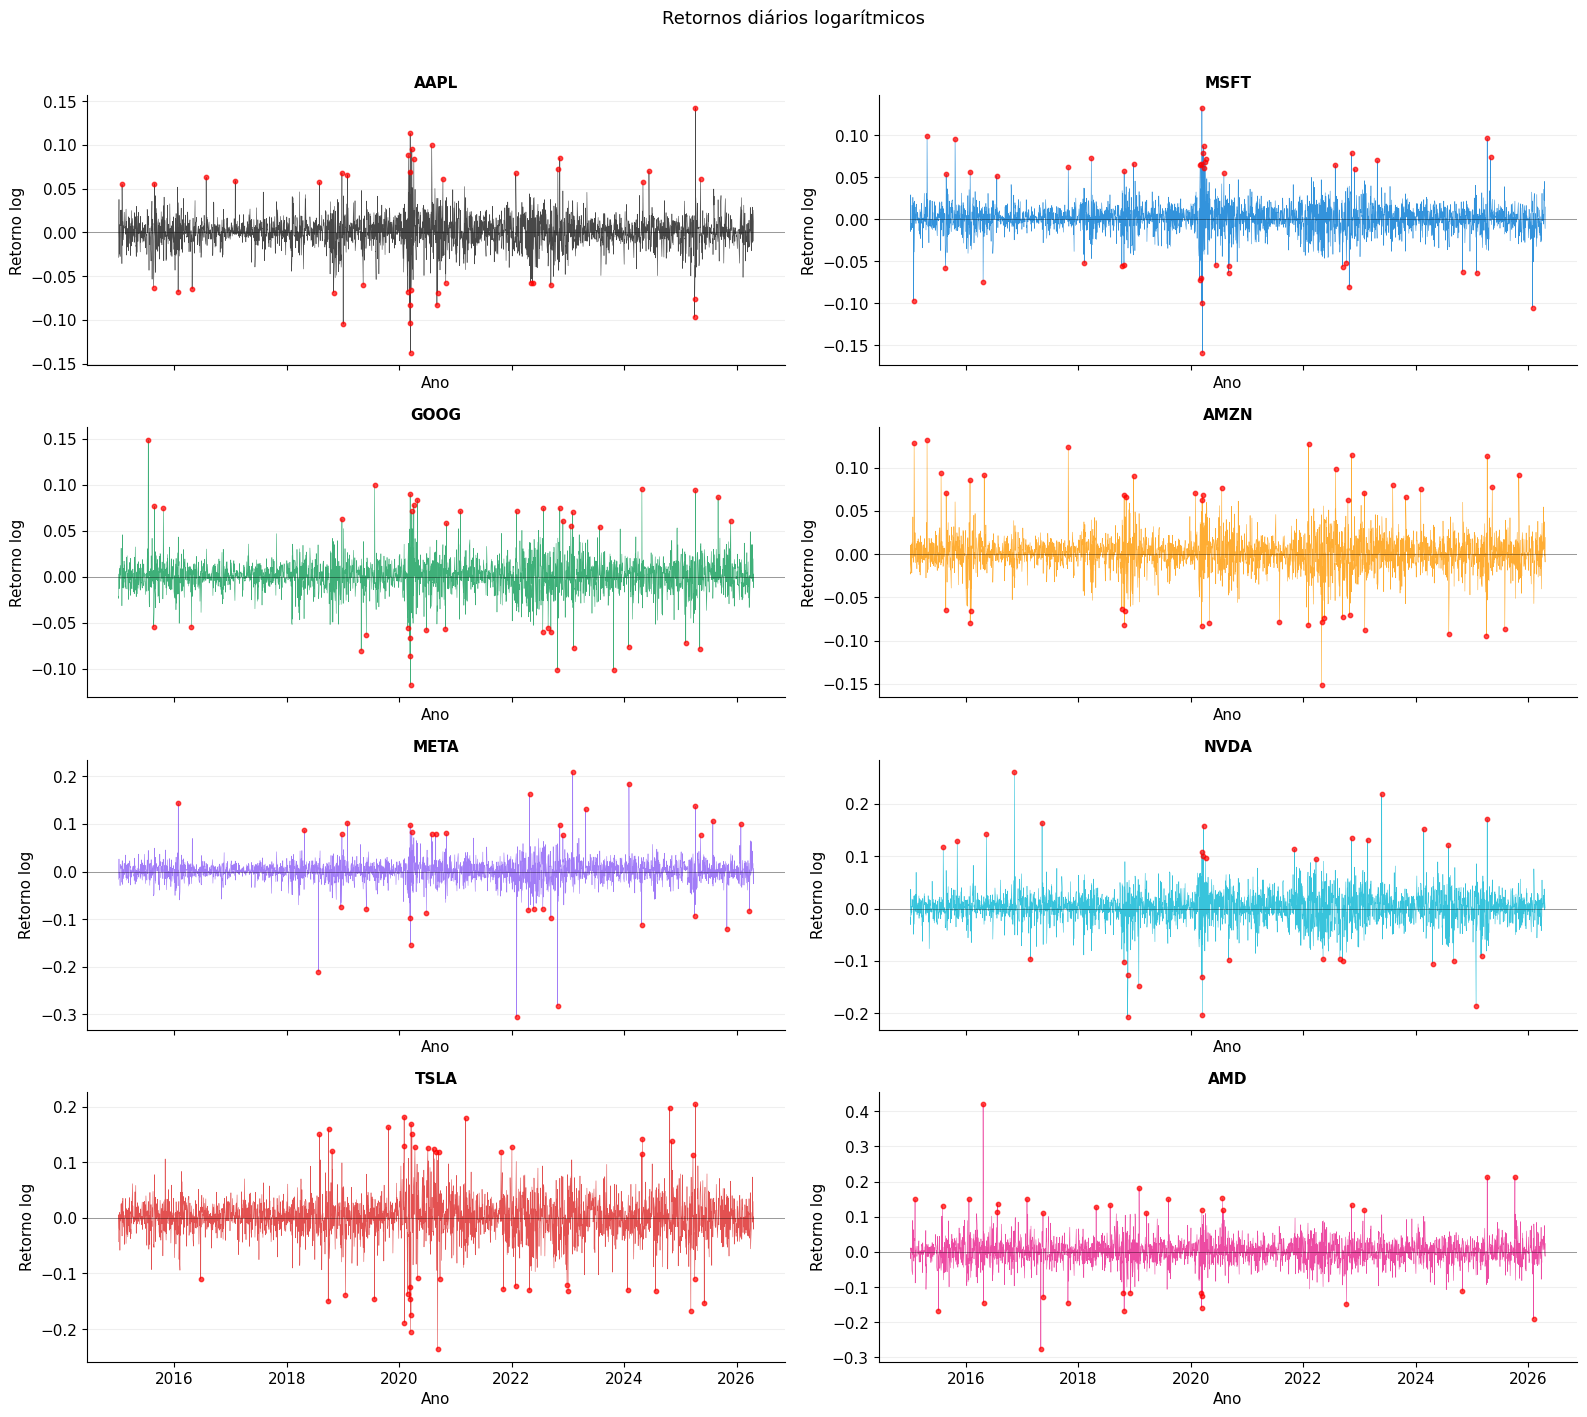

In [64]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for ax, ticker in zip(axes, TICKERS):
    ax.plot(log_returns.index, log_returns[ticker],
            color=COLORS[ticker], linewidth=0.4, alpha=0.8)
    ax.axhline(y=0, color='black', linewidth=0.5, alpha=0.5)
    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.set_ylabel('Retorno log')
    ax.set_xlabel('Ano')
    ax.grid(axis='y', alpha=0.2)
    
    # Destacar retornos extremos (> 3 desvios-padrão)
    threshold = log_returns[ticker].std() * 3
    extremes = log_returns[ticker][log_returns[ticker].abs() > threshold]
    ax.scatter(extremes.index, extremes.values, color='red', s=10, zorder=5, alpha=0.7)

plt.suptitle('Retornos diários logarítmicos',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

Os pontos vermelhos marcam retornos além de 3 desvios-padrão — eventos que seriam extremamente raros sob normalidade (~0.3% de chance) mas que ocorrem com frequência notável. Isso é a primeira evidência visual de caudas pesadas.

### 2.5 Distribuição dos retornos

Compara-se o formato da distribuição observada com a curva normal teórica (linha pontilhada). Se os retornos fossem normalmente distribuídos, o histograma deveria se encaixar sob a curva. O que se observa é um padrão de leptocurtose: o pico central do histograma é mais alto que a normal (retornos se concentram mais perto de zero do que o esperado) e as extremidades mostram barras onde a curva normal já está em zero (eventos extremos mais frequentes). A distribuição observada a partir dos dados concentra mais massa no centro e nas caudas, tirando massa da região intermediária.

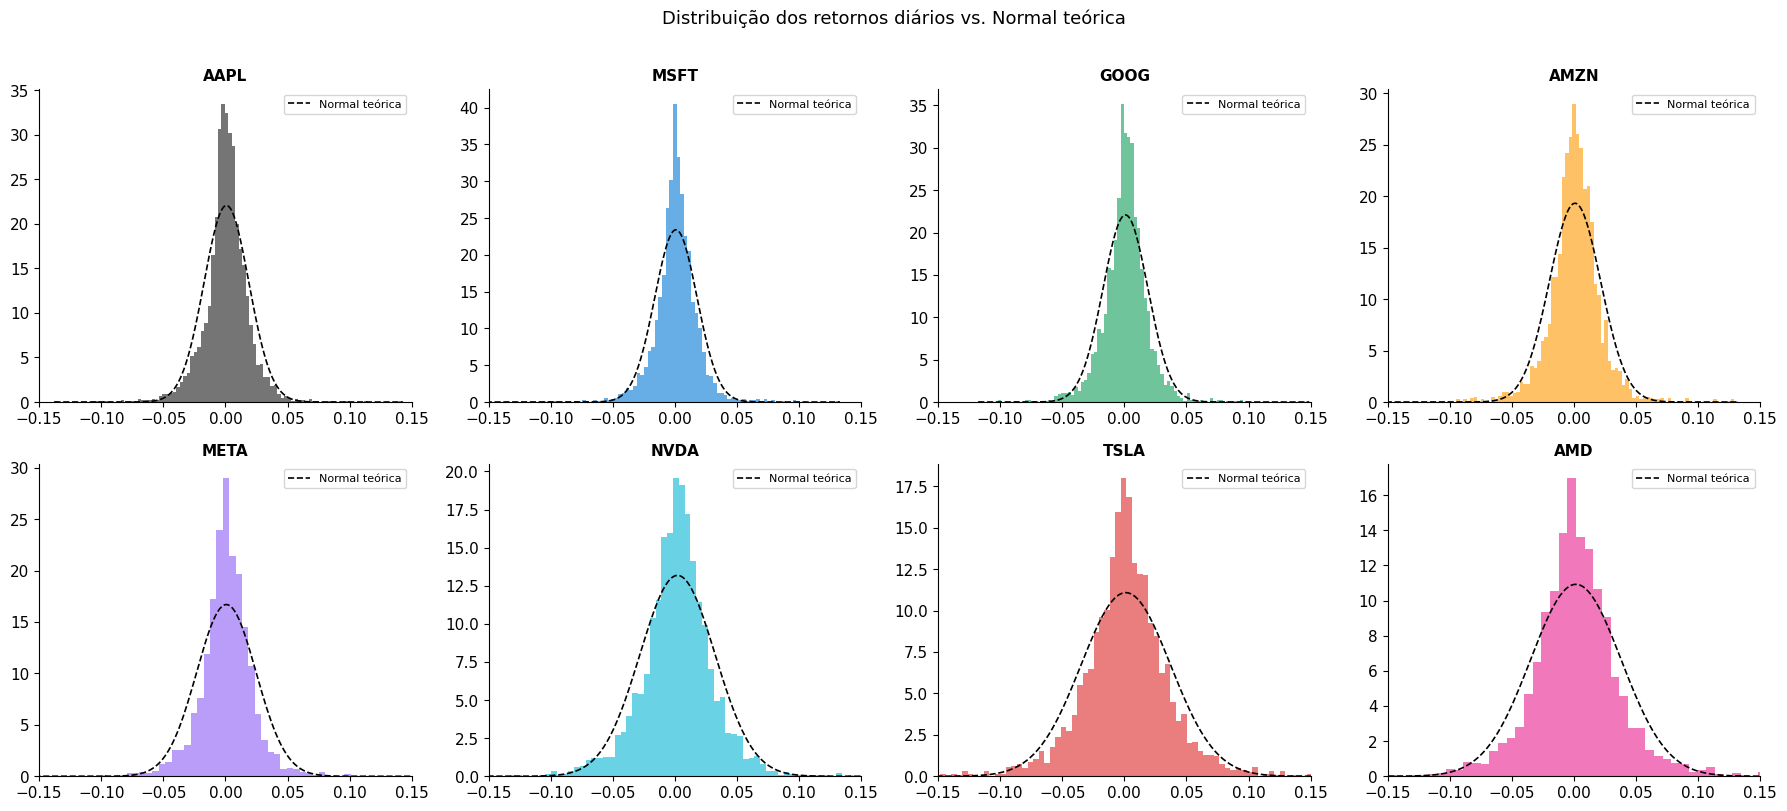

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, ticker in zip(axes, TICKERS):
    data_r = log_returns[ticker].dropna()
    
    # Histograma
    ax.hist(data_r, bins=100, density=True, alpha=0.6,
            color=COLORS[ticker], edgecolor='none')
    
    # Curva normal teórica
    x = np.linspace(data_r.min(), data_r.max(), 300)
    ax.plot(x, stats.norm.pdf(x, data_r.mean(), data_r.std()),
            'k--', linewidth=1.2, label='Normal teórica')
    
    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.set_xlim(-0.15, 0.15)

plt.suptitle('Distribuição dos retornos diários vs. Normal teórica', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.6 QQ-Plot contra a normal

O QQ-plot compara os quantis teóricos de uma normal (eixo x) contra os quantis observados nos dados reais (eixo y). Se os retornos fossem normais, os pontos cairiam sobre a linha diagonal. Desvios na cauda esquerda (pontos abaixo da linha) indicam que as quedas extremas reais são piores do que a normal prevê. Desvios na cauda direita (pontos acima da linha) indicam rallies (altas) mais intensos que o esperado. Esse padrão em "S" esticado é a assinatura visual de caudas pesadas.

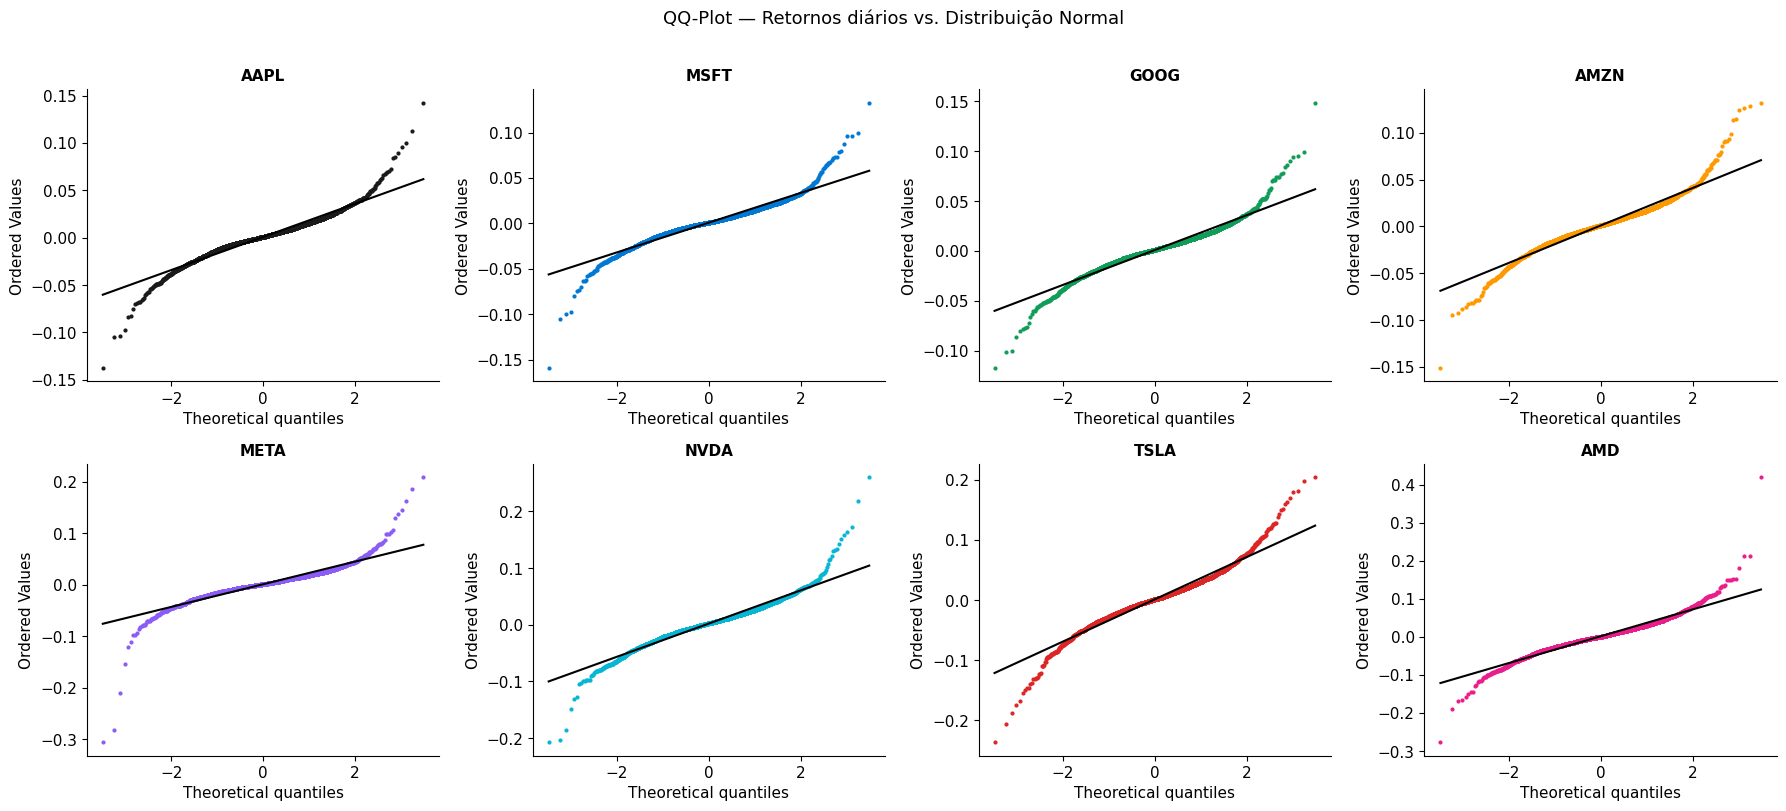

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, ticker in zip(axes, TICKERS):
    stats.probplot(log_returns[ticker].dropna(), dist="norm", plot=ax)
    ax.set_title(ticker, fontsize=11, fontweight='bold')
    ax.get_lines()[0].set_color(COLORS[ticker])
    ax.get_lines()[0].set_markersize(2)
    ax.get_lines()[1].set_color('black')

plt.suptitle('QQ-Plot — Retornos diários vs. Distribuição Normal', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 2.7 Volume de negociação

O volume mede a quantidade de ações negociadas em cada dia e é interessante visualizar o comportamento dessa feature ao longo do tempo.

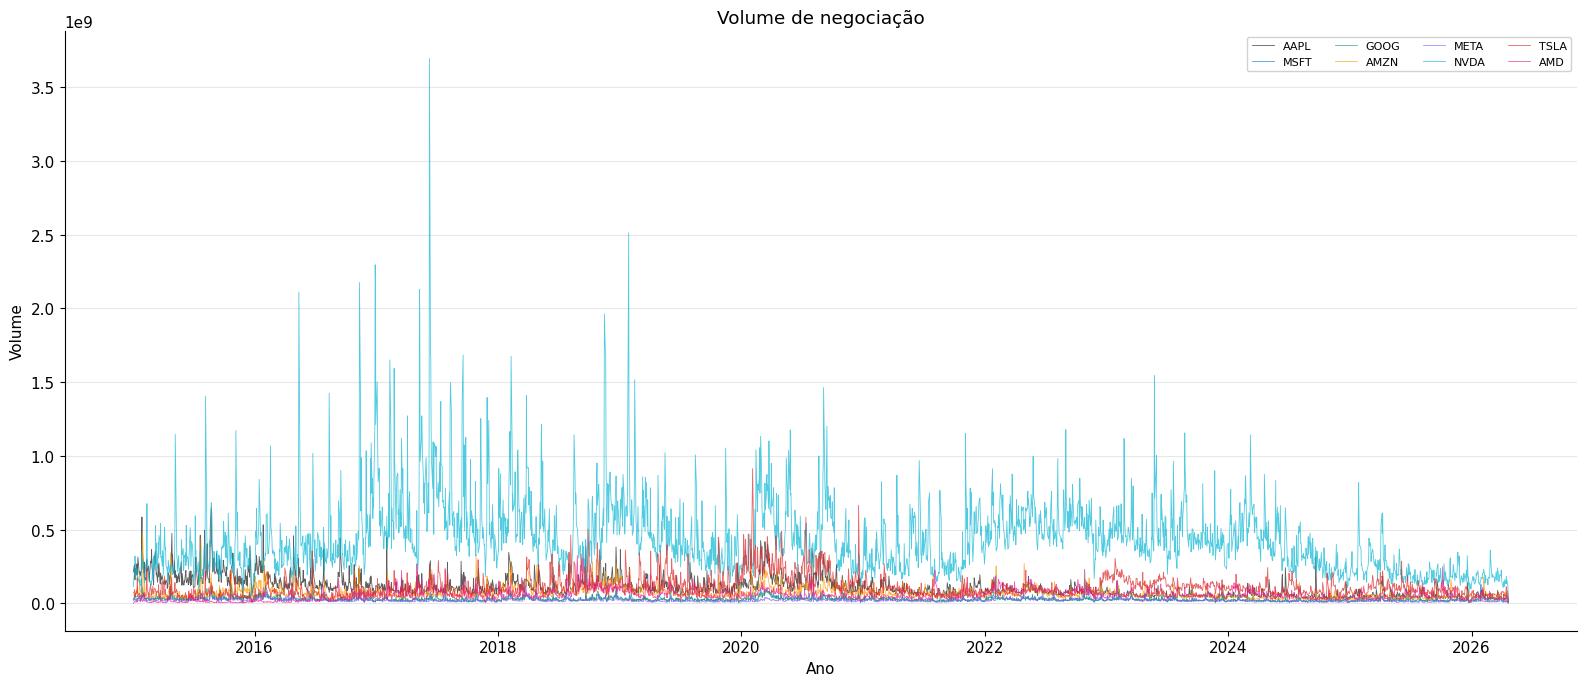

In [65]:
# Volume de negociação ao longo do tempo
fig, ax = plt.subplots(figsize=(16, 7))

# Com NVDA
#ax = axes[0]
for ticker in TICKERS:
    ax.plot(volume.index, volume[ticker], label=ticker,
            color=COLORS[ticker], linewidth=0.6, alpha=0.7)
ax.set_ylabel('Volume')
ax.set_xlabel('Ano')
ax.set_title('Volume de negociação')
ax.legend(loc='upper right', framealpha=0.9, ncol=4, fontsize=8)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### 2.8 Volume relativo vs. retorno — Dias extremos têm volume maior?

O volume relativo (volume do dia dividido pela média dos últimos 20 dias) normaliza a atividade contra o passado recente, eliminando a tendência de queda do volume absoluto. Cruzando com os retornos, verificamos se dias com retornos extremos coincidem com volume anormalmente alto.

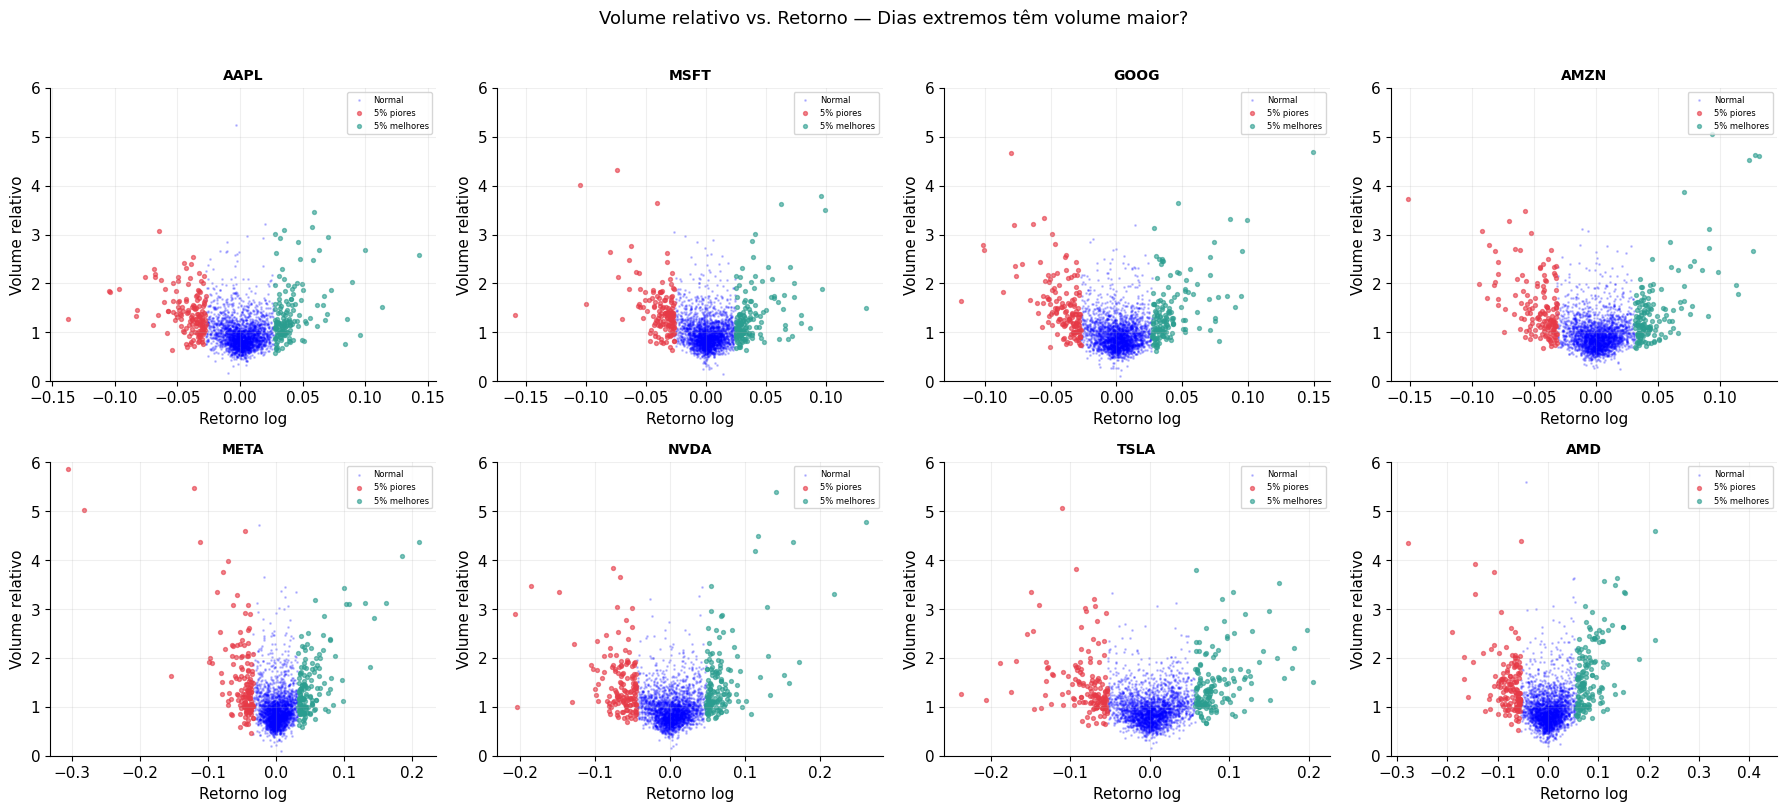

Ticker    Vol.rel normal  Vol.rel 5% piores  Vol.rel 5% melhores
-----------------------------------------------------------------
AAPL                0.96               1.41                 1.39
MSFT                0.96               1.47                 1.34
GOOG                0.95               1.53                 1.45
AMZN                0.95               1.51                 1.46
META                0.95               1.65                 1.48
NVDA                0.95               1.49                 1.57
TSLA                0.95               1.49                 1.50
AMD                 0.94               1.50                 1.75


In [12]:
# Volume relativo nos dias normais vs. dias extremos
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, ticker in zip(axes, TICKERS):
    ret = log_returns[ticker]
    vol_rel = volume[ticker] / volume[ticker].rolling(20).mean()
    
    # Alinhar índices
    df_vol = pd.DataFrame({'ret': ret, 'vol_rel': vol_rel}).dropna()
    
    # Classificar dias
    threshold_low = df_vol['ret'].quantile(0.05)
    threshold_high = df_vol['ret'].quantile(0.95)
    
    normal = df_vol[(df_vol['ret'] > threshold_low) & (df_vol['ret'] < threshold_high)]
    extreme_neg = df_vol[df_vol['ret'] <= threshold_low]
    extreme_pos = df_vol[df_vol['ret'] >= threshold_high]
    
    ax.scatter(normal['ret'], normal['vol_rel'], s=1, alpha=0.2, color='blue', label='Normal')
    ax.scatter(extreme_neg['ret'], extreme_neg['vol_rel'], s=8, alpha=0.6, color='#E63946', label='5% piores')
    ax.scatter(extreme_pos['ret'], extreme_pos['vol_rel'], s=8, alpha=0.6, color='#2A9D8F', label='5% melhores')
    
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.set_xlabel('Retorno log')
    ax.set_ylabel('Volume relativo')
    ax.set_ylim(0, 6)
    ax.legend(fontsize=6, loc='upper right')
    ax.grid(alpha=0.2)

plt.suptitle('Volume relativo vs. Retorno — Dias extremos têm volume maior?', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

# Tabela resumo
print(f"{'Ticker':<8} {'Vol.rel normal':>15} {'Vol.rel 5% piores':>18} {'Vol.rel 5% melhores':>20}")
print("-" * 65)
for ticker in TICKERS:
    ret = log_returns[ticker]
    vol_rel = volume[ticker] / volume[ticker].rolling(20).mean()
    df_vol = pd.DataFrame({'ret': ret, 'vol_rel': vol_rel}).dropna()
    
    tl = df_vol['ret'].quantile(0.05)
    th = df_vol['ret'].quantile(0.95)
    
    normal_mean = df_vol[(df_vol['ret'] > tl) & (df_vol['ret'] < th)]['vol_rel'].mean()
    neg_mean = df_vol[df_vol['ret'] <= tl]['vol_rel'].mean()
    pos_mean = df_vol[df_vol['ret'] >= th]['vol_rel'].mean()
    
    print(f"{ticker:<8} {normal_mean:>15.2f} {neg_mean:>18.2f} {pos_mean:>20.2f}")

O padrão é claro e consistente: dias com retornos extremos, tanto negativos quanto positivos, têm volume significativamente acima da média. O formato em "V" confirma que o volume está correlacionado com o valor absoluto do retorno, não com a direção.

### 2.9 Correlação de Pearson

A correlação de Pearson entre os retornos diários dá uma visão geral da co-movimentação entre as ações ao longo de todo o período. É importante notar que Pearson mede dependência linear e simétrica — assume que a relação entre as ações é a mesma nos dias bons e nos dias ruins. Veremos mais adiante, com a análise de copulas, que essa premissa não se sustenta.

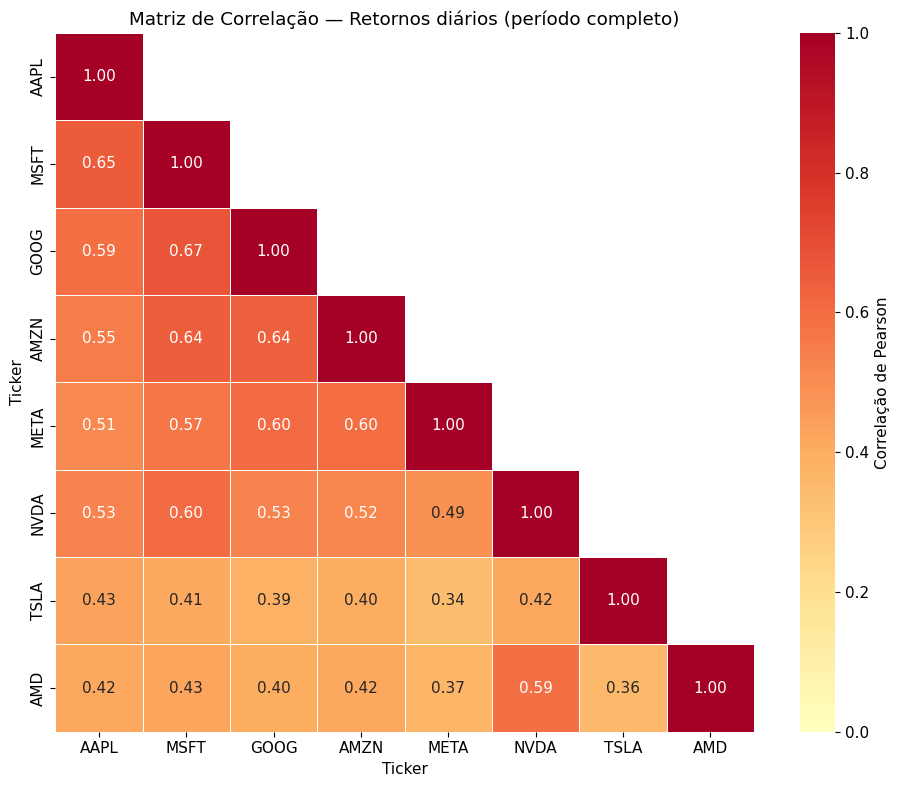

In [13]:
corr_matrix = log_returns.corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=0, vmax=1, square=True,
            linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Correlação de Pearson'})
ax.set_title('Matriz de Correlação — Retornos diários (período completo)')
plt.tight_layout()
plt.show()

### 2.10 Rolling Correlation — A correlação não é constante

A matriz acima é uma média de todo o período. Mas a correlação muda ao longo do tempo — e tende a **aumentar em momentos de estresse**, justamente quando a diversificação seria mais necessária. Usamos uma janela móvel de 60 dias úteis (~3 meses) para visualizar essa dinâmica.

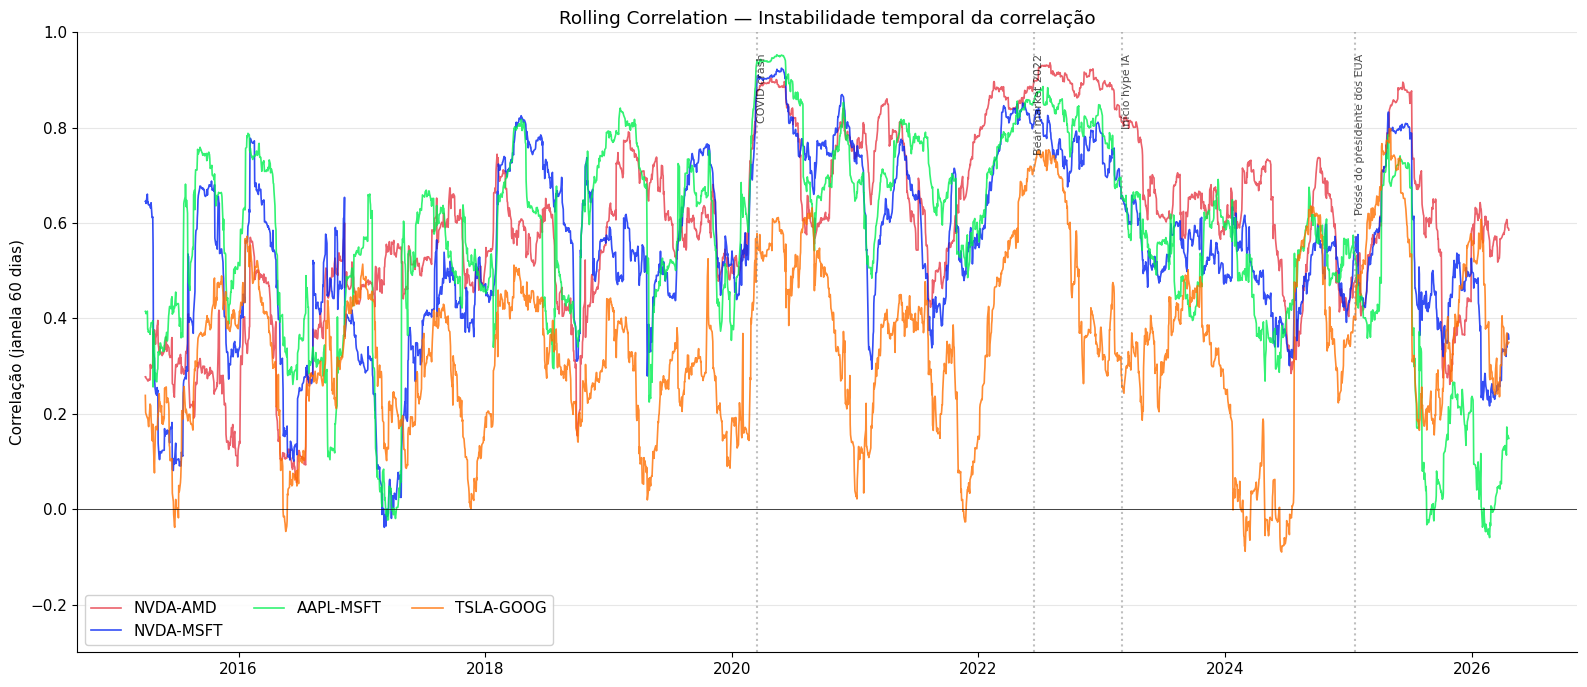

In [14]:
# Rolling correlation de pares selecionados (com NVDA como referência)
rolling_window = 60
pairs = [('NVDA', 'AMD'), ('NVDA', 'MSFT'),
         ('AAPL', 'MSFT'), ('TSLA', 'GOOG')]

fig, ax = plt.subplots(figsize=(16, 7))

pair_colors = ['#E63946', "#0122F3", "#00EF50", "#FF6F00"]

for (t1, t2), color in zip(pairs, pair_colors):
    rolling_corr = log_returns[t1].rolling(rolling_window).corr(log_returns[t2])
    ax.plot(rolling_corr.index, rolling_corr, label=f'{t1}-{t2}',
            linewidth=1.2, alpha=0.8, color=color)

# Eventos de mercado
events = {
    '2020-03-15': 'COVID crash',
    '2022-06-15': 'Bear market 2022',
    '2023-03-01': 'Início hype IA',
    '2025-01-20': 'Posse do presidente dos EUA'
}
for date, label in events.items():
    ax.axvline(pd.Timestamp(date), color='gray', linestyle=':', alpha=0.5)
    ax.text(pd.Timestamp(date), ax.get_ylim()[1] * 0.95, label,
            rotation=90, fontsize=8, alpha=0.7, va='top')

ax.set_ylabel('Correlação (janela 60 dias)')
ax.set_title('Rolling Correlation — Instabilidade temporal da correlação')
ax.legend(loc='lower left', framealpha=0.9, ncol=3)
ax.axhline(y=0, color='black', linewidth=0.5)
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(-0.3, 1.0)
plt.tight_layout()
plt.show()

A rolling correlation revela que a correlação entre big techs é fundamentalmente instável. Em momentos de crise como a COVID (março 2020), quase todas as correlações convergem para 0,8-0,95. Em períodos normais, a dispersão é grande. Note que o par NVDA e AMD mantêm correlação consistentemente alta, uma das explicações para isso é que ambas estão no segmento de semicondutores.

### 2.11 Evolução da correlação da NVDA com as demais

A NVDA teve um crescimento desproporcional em relação às demais big techs. Verificamos como isso afetou sua correlação com o grupo.

In [15]:
# Correlação média entre NVDA e todas as outras, pré e pós hype IA
cutoff = pd.Timestamp('2023-01-01')
others = [t for t in TICKERS if t != 'NVDA']

pre_ia = log_returns.loc[:cutoff]
post_ia = log_returns.loc[cutoff:]

corr_pre = pre_ia[['NVDA'] + others].corr().loc['NVDA', others]
corr_post = post_ia[['NVDA'] + others].corr().loc['NVDA', others]

comparison = pd.DataFrame({
    'Pré-2023': corr_pre,
    'Pós-2023': corr_post,
    'Variação': corr_post - corr_pre
}).round(3)

print("Correlação de NVDA com cada ação — Pré vs. Pós hype de IA:")
print(comparison)
print(f"\nCorrelação média pré-2023:  {corr_pre.mean():.3f}")
print(f"Correlação média pós-2023: {corr_post.mean():.3f}")

Correlação de NVDA com cada ação — Pré vs. Pós hype de IA:
        Pré-2023  Pós-2023  Variação
Ticker                              
AAPL       0.588     0.371    -0.217
MSFT       0.635     0.514    -0.122
GOOG       0.577     0.406    -0.171
AMZN       0.544     0.455    -0.089
META       0.499     0.451    -0.048
TSLA       0.434     0.390    -0.044
AMD        0.591     0.597     0.006

Correlação média pré-2023:  0.553
Correlação média pós-2023: 0.455


A correlação da NVDA com a maioria das ações **diminuiu** a partir de 2023, com exceção da AMD. A explicação mais provável é que a NVDA cresceu de forma tão desproporcional que se descolou do grupo, passando a responder a drivers próprios (como demanda por GPUs de data center e ganhos de magnitude inédita) que não afetam as demais na mesma escala. A AMD manteve correlação alta provavelmente por compartilhar os mesmos fundamentos de negócio.

### 2.12 Copulas — Dependência nas caudas

A correlação de Pearson mede dependência linear e simétrica — trata a relação entre duas ações da mesma forma em dias normais e em dias de crash. Copulas separam a estrutura de dependência das distribuições individuais, permitindo verificar se essa dependência é diferente nas caudas da distribuição.

Transformamos os retornos em "pseudo-observações" (rank transform para escala uniforme 0-1) e visualizamos a concentração de pontos nos cantos: mais pontos no canto inferior esquerdo (quedas conjuntas) do que no canto superior direito (altas conjuntas) indica dependência assimétrica.

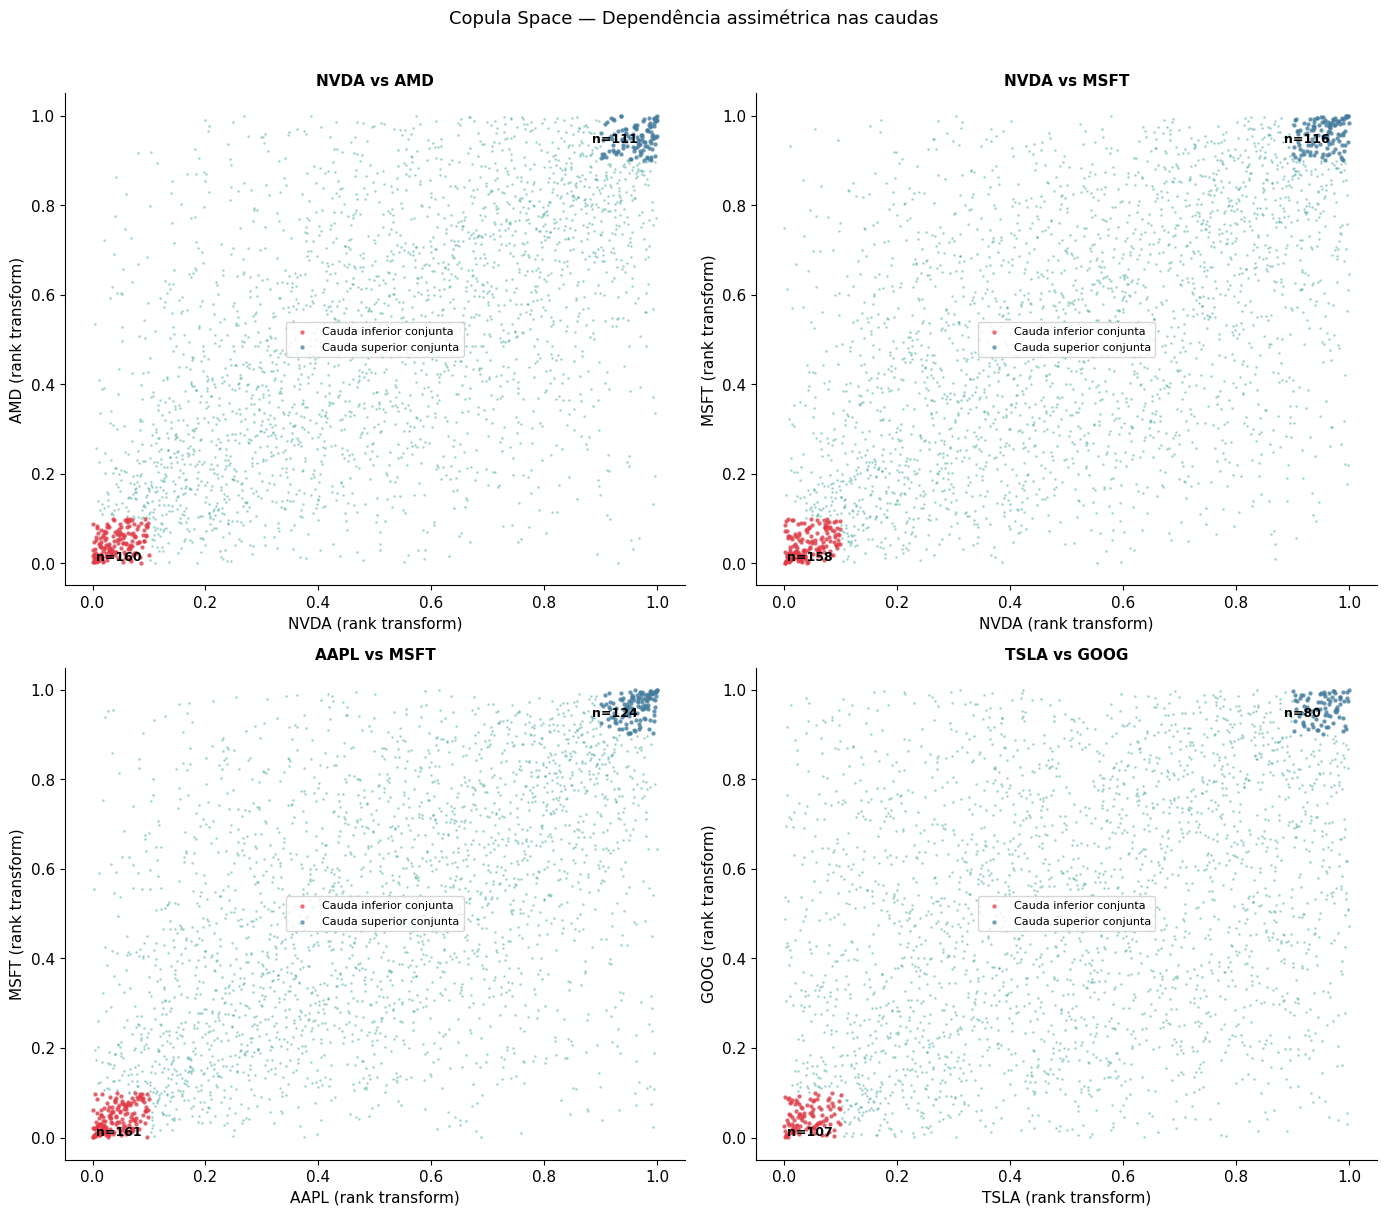

In [16]:
from scipy.stats import rankdata

def pseudo_observations(x):
    """Transforma dados em pseudo-observações (uniforme) via rank transform."""
    n = len(x)
    return rankdata(x) / (n + 1)

# Pares de interesse
pairs_copula = [('NVDA', 'AMD'), ('NVDA', 'MSFT'), ('AAPL', 'MSFT'), ('TSLA', 'GOOG')]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, (t1, t2) in zip(axes, pairs_copula):
    u1 = pseudo_observations(log_returns[t1].values)
    u2 = pseudo_observations(log_returns[t2].values)
    
    ax.scatter(u1, u2, s=1, alpha=0.3, color='#2A9D8F')
    
    # Destacar caudas conjuntas (abaixo de 10% ou acima de 90%)
    lower_tail = (u1 < 0.10) & (u2 < 0.10)
    upper_tail = (u1 > 0.90) & (u2 > 0.90)
    
    ax.scatter(u1[lower_tail], u2[lower_tail], s=5, color='#E63946', alpha=0.6, label='Cauda inferior conjunta')
    ax.scatter(u1[upper_tail], u2[upper_tail], s=5, color='#457B9D', alpha=0.6, label='Cauda superior conjunta')
    
    n_lower = lower_tail.sum()
    n_upper = upper_tail.sum()
    
    ax.set_title(f'{t1} vs {t2}', fontsize=11, fontweight='bold')
    ax.set_xlabel(f'{t1} (rank transform)')
    ax.set_ylabel(f'{t2} (rank transform)')
    ax.legend(fontsize=8, loc='center')
    
    ax.text(0.05, 0.05, f'n={n_lower}', fontsize=9, color="#000000", 
            transform=ax.transAxes, fontweight='bold')
    ax.text(0.85, 0.90, f'n={n_upper}', fontsize=9, color="#000000",
            transform=ax.transAxes, fontweight='bold')

plt.suptitle('Copula Space — Dependência assimétrica nas caudas', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Coeficiente de dependência nas caudas (tail dependence) — empírico
print("Dependência empírica nas caudas (threshold = 10%):")
print(f"{'Par':<20} {'Cauda inferior':>15} {'Cauda superior':>15} {'Razão (inf/sup)':>18}")
print("-" * 70)

for t1, t2 in pairs_copula:
    u1 = pseudo_observations(log_returns[t1].values)
    u2 = pseudo_observations(log_returns[t2].values)
    
    q = 0.10
    lower = np.mean((u1 < q) & (u2 < q)) / q
    upper = np.mean((u1 > 1-q) & (u2 > 1-q)) / q
    ratio = lower / upper if upper > 0 else float('inf')
    
    print(f"{t1+'-'+t2:<20} {lower:>15.4f} {upper:>15.4f} {ratio:>18.2f}")

print("\nRazão > 1 indica que as ações caem juntas com mais frequência do que sobem juntas.")

Dependência empírica nas caudas (threshold = 10%):
Par                   Cauda inferior  Cauda superior    Razão (inf/sup)
----------------------------------------------------------------------
NVDA-AMD                      0.5634          0.3908               1.44
NVDA-MSFT                     0.5563          0.4085               1.36
AAPL-MSFT                     0.5669          0.4366               1.30
TSLA-GOOG                     0.3768          0.2817               1.34

Razão > 1 indica que as ações caem juntas com mais frequência do que sobem juntas.
Quanto maior a razão, mais assimétrica a dependência.
Essa assimetria é exatamente o que a correlação de Pearson esconde.


Em todos os pares, a razão cauda inferior/superior é maior que 1: as ações caem juntas com mais frequência do que sobem juntas. Essa assimetria é exatamente o que a correlação de Pearson esconde ao reportar um número único. A implicação prática é que a diversificação entre big techs funciona nos dias bons mas falha parcialmente nos dias ruins, exatamente quando seria mais necessária.

### 2.13 Decomposição de Fatores (PCA)

A Análise de Componentes Principais decompõe os retornos em fatores ortogonais que explicam a variância máxima. O primeiro componente (PC1) tipicamente captura o "fator mercado" (o movimento comum a todas as ações). Componentes subsequentes capturam diferenciações dentro do grupo, e sua interpretação exige análise dos loadings (o peso de cada ação em cada componente).

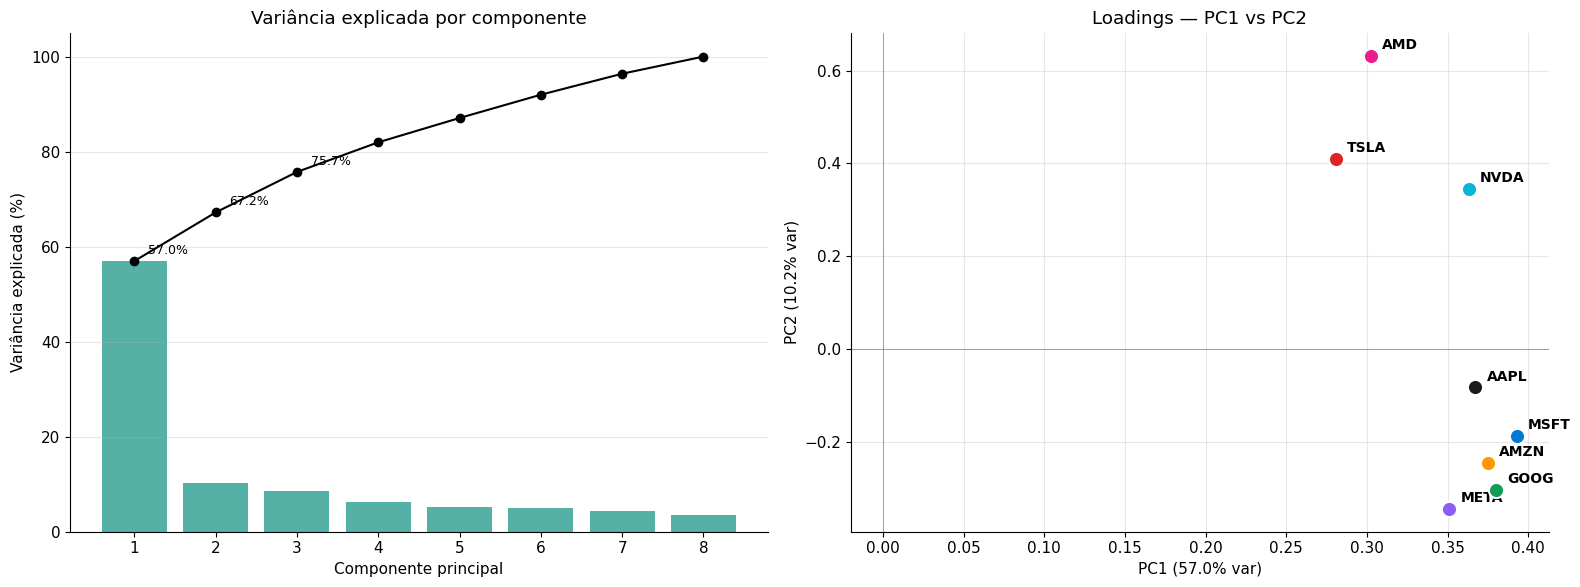

In [18]:
# PCA nos retornos padronizados
returns_std = (log_returns - log_returns.mean()) / log_returns.std()

pca = PCA()
pca.fit(returns_std)

# Variância explicada
explained = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Variância explicada por componente
ax = axes[0]
ax.bar(range(1, len(explained)+1), explained * 100, color='#2A9D8F', alpha=0.8, edgecolor='none')
ax.plot(range(1, len(explained)+1), cumulative_var * 100, 'ko-', markersize=6)
ax.set_xlabel('Componente principal')
ax.set_ylabel('Variância explicada (%)')
ax.set_title('Variância explicada por componente')
ax.set_xticks(range(1, len(explained)+1))
ax.grid(axis='y', alpha=0.3)

for i, (e, c) in enumerate(zip(explained, cumulative_var)):
    if i < 3:
        ax.annotate(f'{c*100:.1f}%', (i+1, c*100), textcoords="offset points",
                    xytext=(10, 5), fontsize=9)

# Loadings dos 2 primeiros componentes
ax = axes[1]
loadings = pd.DataFrame(pca.components_[:2].T, columns=['PC1', 'PC2'], index=TICKERS)

for ticker in TICKERS:
    ax.scatter(loadings.loc[ticker, 'PC1'], loadings.loc[ticker, 'PC2'],
               color=COLORS[ticker], s=120, zorder=5, edgecolor='white', linewidth=1.5)
    ax.annotate(ticker, (loadings.loc[ticker, 'PC1'], loadings.loc[ticker, 'PC2']),
                textcoords="offset points", xytext=(8, 5), fontsize=10, fontweight='bold')

ax.axhline(y=0, color='gray', linewidth=0.5)
ax.axvline(x=0, color='gray', linewidth=0.5)
ax.set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
ax.set_title('Loadings — PC1 vs PC2')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

O PC1 explica a maior parte da variância, confirmando que as big techs são dominadas por um fator comum (o mercado). O gráfico de loadings revela dois subgrupos: AMD, TSLA e NVDA (ações de alto crescimento/volatilidade) se posicionam na parte superior, enquanto MSFT, GOOG, AMZN e META (ações mais maduras e estáveis) ficam na parte inferior. O PCA descobre essa diferenciação diretamente dos dados, sem informação prévia sobre os setores.

### 2.14 Regimes de mercado — Hidden Markov Models

Os gráficos de retornos diários e de volatilidade realizada mostram que o mercado alterna entre períodos calmos e períodos turbulentos. O Hidden Markov Model formaliza essa observação: assume que existe um estado latente (que não observamos diretamente) que governa o comportamento dos retornos. Com 2 estados, o HMM identifica um regime de baixa volatilidade e um de alta volatilidade, estimando os parâmetros de cada um e as probabilidades de transição entre eles.

In [68]:
from hmmlearn.hmm import GaussianHMM

# Ajustar HMM com 2 estados para NVDA
ticker_hmm = 'NVDA'
returns_hmm = log_returns[ticker_hmm].dropna().values.reshape(-1, 1)

# Treinar modelo
model = GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=42)
model.fit(returns_hmm)

# Sequência de estados
hidden_states = model.predict(returns_hmm)

# Garantir que estado 0 = baixa volatilidade
if model.covars_[0][0][0] > model.covars_[1][0][0]:
    hidden_states = 1 - hidden_states
    means = [model.means_[1][0], model.means_[0][0]]
    vols = [np.sqrt(model.covars_[1][0][0]), np.sqrt(model.covars_[0][0][0])]
    trans_mat = model.transmat_[[1,0]][:,[1,0]]
else:
    means = [model.means_[0][0], model.means_[1][0]]
    vols = [np.sqrt(model.covars_[0][0][0]), np.sqrt(model.covars_[1][0][0])]
    trans_mat = model.transmat_

print(f"Parâmetros estimados para {ticker_hmm}:")
print(f"\nRegime 0 (Baixa volatilidade):")
print(f"Média diária: {means[0]*100:.3f}%")
print(f"Vol diária: {vols[0]*100:.3f}%")
print(f"Vol anualizada: {vols[0]*np.sqrt(252)*100:.3f}%")
print(f"\nRegime 1 (Alta volatilidade):")
print(f"Média diária: {means[1]*100:.3f}%")
print(f"Vol diária: {vols[1]*100:.3f}%")
print(f"Vol anualizada: {vols[1]*np.sqrt(252)*100:.3f}%")
print(f"\nMatriz de transição:")
print(f"P(ficar em regime 0) = {trans_mat[0,0]:.3f}")
print(f"P(mudar 0 → 1) = {trans_mat[0,1]:.3f}")
print(f"P(mudar 1 → 0) = {trans_mat[1,0]:.3f}")
print(f"P(ficar em regime 1) = {trans_mat[1,1]:.3f}")

Parâmetros estimados para NVDA:

Regime 0 (Baixa volatilidade):
Média diária: 0.307%
Vol diária: 1.974%
Vol anualizada: 31.332%

Regime 1 (Alta volatilidade):
Média diária: -0.023%
Vol diária: 4.735%
Vol anualizada: 75.159%

Matriz de transição:
P(ficar em regime 0) = 0.968
P(mudar 0 → 1) = 0.032
P(mudar 1 → 0) = 0.079
P(ficar em regime 1) = 0.921


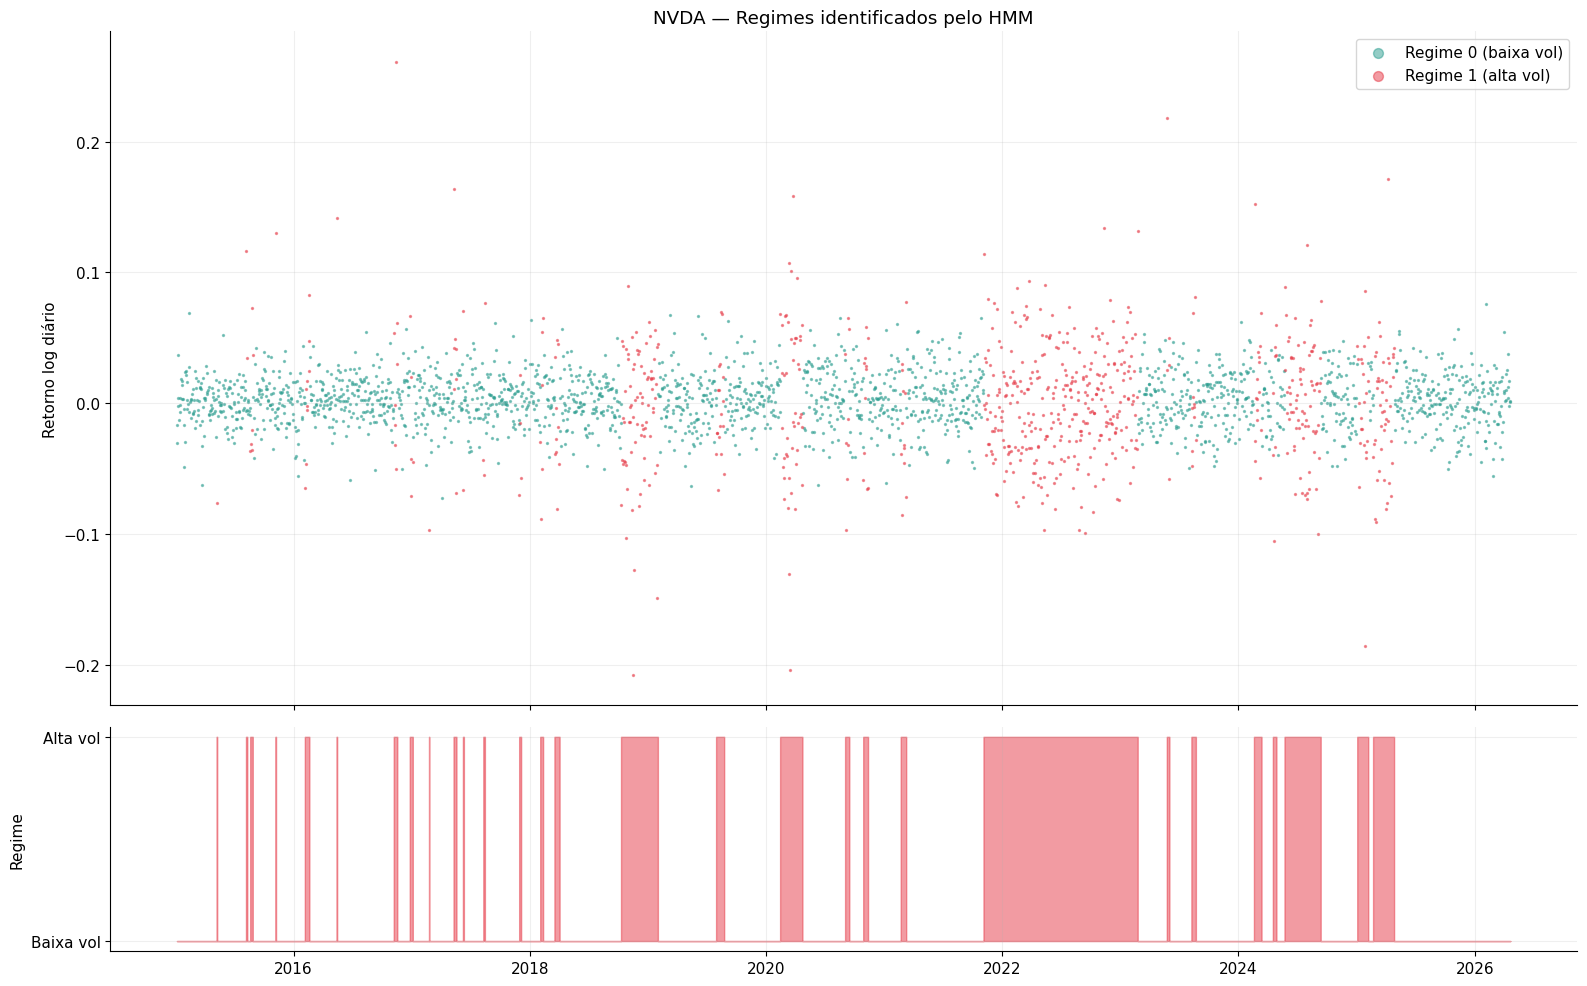

In [69]:
# Visualização dos regimes
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True,
                         gridspec_kw={'height_ratios': [3, 1]})

dates_hmm = log_returns.index

# Painel superior: retornos com regimes
ax = axes[0]
colors_regime = ['#2A9D8F', '#E63946']
for state in [0, 1]:
    mask = hidden_states == state
    ax.scatter(dates_hmm[mask], returns_hmm[mask], c=colors_regime[state],
               s=2, alpha=0.5, label=f'Regime {state} ({"baixa" if state==0 else "alta"} vol)')

ax.set_ylabel('Retorno log diário')
ax.set_title(f'{ticker_hmm} — Regimes identificados pelo HMM')
ax.legend(markerscale=5)
ax.grid(alpha=0.2)

# Painel inferior: estado ao longo do tempo
ax = axes[1]
ax.fill_between(dates_hmm, hidden_states, step='mid', alpha=0.5, color='#E63946')
ax.set_ylabel('Regime')
ax.set_yticks([0, 1])
ax.set_yticklabels(['Baixa vol', 'Alta vol'])
ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

**Reflexão da Análise Exploratória:** todas as empresas tiveram um desempenho muito bom no período analisado, com destaque para a Nvidia, que acumulou um retorno de mais de 40.000%. Outra empresa que se destacou foi a AMD, que, assim como a Nvidia, também está no segmento de semicondutores. Analisando mais a fundo o retorno de cada ação, nota-se que a distribuição é bem mais "pontuda" do que se esperava da normal teórica; aqui temos um sinal de que o reotorno das ações não seguem uma distribuição normal. Para confirmar a hipótese de não normalidade, foi feito um QQ-plot da distribuição de cada ação contra a distribuição normal e as cudas pesadas apareceram. Outro aspecto interessante sobre o retorno é que ele possui uma relação interessante com o volume de negociação, para todas as ações o volume é maior em dias de retornos extremos (tanto negativos quanto positivos). Outro aspecto analisado foi a correlação entre essas ações. Primeiro, observando a correlação de Pearson, tem-se que a correlação entre a maioria das empresas é considerável, entre 0,5 e 0,65, mas nada muito elevado fora do esperado. Analisando correlações durante o tempo, é possível ientificar um momento de correlação altíssima (pandemia de COVID-19), mas em geral essas correlações não são instáveis ao longo do tempo. Uma última análise de correlação foi feita usando copula e o resultado é bastante interessante, as ações, assim como mostrada na correlação de Pearson não são tão correlacionadas, mas essa correlação tende a aumentrar nas caudas (eventos extremos), em especial na cauda negativa, indicando que em momentos ruins as ações tendem a cair juntas, mas isso não acontece com a mesma intensidade em momentos bons. Caminhando para o fim da análise exploratória, a o de fatores mostrou que o fator mercado explica mais da metade das variações observadas no grupo de empresa selecionado. Finalmente, terminamos a exploração dos dados usamos HMM mostrar que o mercado se comporta de forma fundamentalmente diferente em diferentes momentos, ou seja, os parâmetros do processo gerador mudam com o tempo.

---

## 3. Análise de Risco

### 3.1 Volatilidade anualizada, Sharpe Ratio e Max Drawdown

A volatilidade anualizada mede a dispersão dos retornos ($\sigma_{anual} = \sigma_{diário} \times \sqrt{252}$). É importante notar que volatilidade não é sinônimo perfeito de risco — ela trata oscilações positivas e negativas igualmente. Métricas como o max drawdown e o VaR capturam dimensões de risco que a volatilidade ignora.

O Sharpe Ratio mede o retorno em excesso por unidade de volatilidade, assumindo taxa livre de risco de ~5% ao ano. O max drawdown é a maior queda do pico ao vale no período.

In [ ]:
risk_free_annual = 0.05
risk_free_daily = risk_free_annual / 252

# Métricas
annual_return = log_returns.mean() * 252
annual_vol = log_returns.std() * np.sqrt(252)
sharpe = (annual_return - risk_free_annual) / annual_vol

# Drawdown máximo
def max_drawdown(returns):
    cum = (1 + returns).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    return dd.min()

max_dd = log_returns.apply(max_drawdown)

risk_df = pd.DataFrame({
    'Retorno médio anual (%)': (annual_return * 100).round(2),
    'Volatilidade anualizada (%)': (annual_vol * 100).round(2),
    'Sharpe Ratio': sharpe.round(3),
    'Max Drawdown (%)': (max_dd * 100).round(2)
}).sort_values('Sharpe Ratio', ascending=False)

risk_df

,Retorno anual (%),Volatilidade anualizada (%),Sharpe Ratio,Max Drawdown (%)
Ticker,,,,
NVDA,53.57,48.05,1.011,-71.87
AMD,41.34,57.96,0.627,-70.99
GOOG,22.73,28.69,0.618,-48.23
AMZN,24.83,32.79,0.605,-61.89
MSFT,21.00,27.06,0.591,-40.61
AAPL,21.41,28.72,0.571,-40.16
TSLA,29.21,57.17,0.423,-79.88
META,19.17,37.93,0.374,-81.75


### 3.2 Risco vs. Retorno

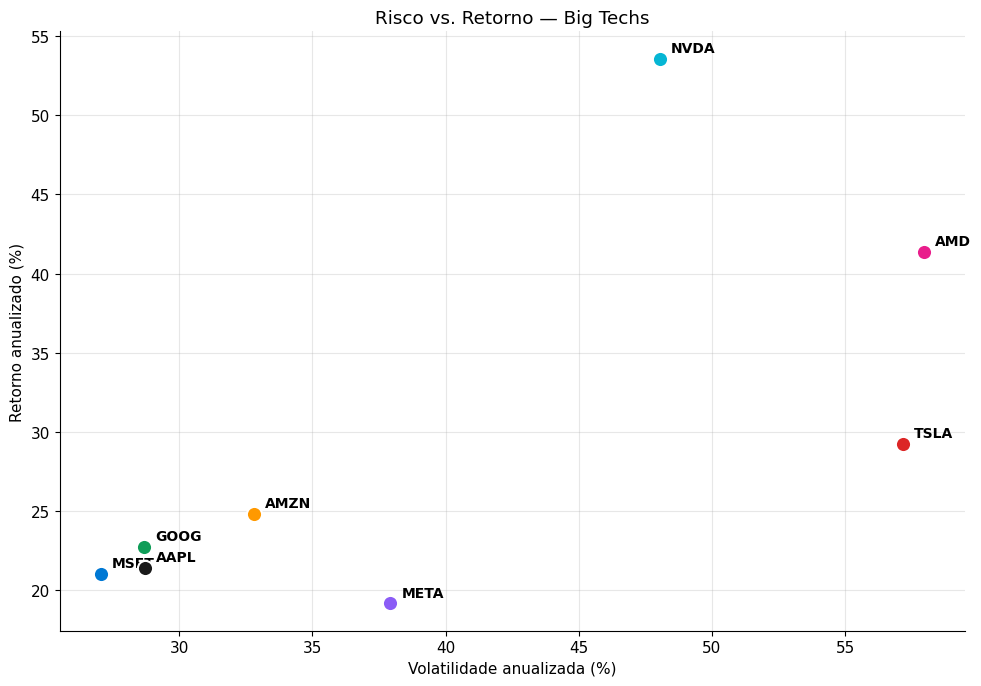

In [22]:
# Visualização risco x retorno
fig, ax = plt.subplots(figsize=(10, 7))

for ticker in TICKERS:
    ax.scatter(annual_vol[ticker] * 100, annual_return[ticker] * 100,
               color=COLORS[ticker], s=120, zorder=5, edgecolor='white', linewidth=1.5)
    ax.annotate(ticker, (annual_vol[ticker] * 100, annual_return[ticker] * 100),
                textcoords="offset points", xytext=(8, 5), fontsize=10, fontweight='bold')

ax.set_xlabel('Volatilidade anualizada (%)')
ax.set_ylabel('Retorno anualizado (%)')
ax.set_title('Risco vs. Retorno — Big Techs')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

O gráfico mostra a relação entre risco (representado por volatilidade) e retorno para cada ação. Ações no canto superior esquerdo (alto retorno, baixa volatilidade) são mais eficientes. É importante lembrar que esses números descrevem o passado; é importante pontuar que projetar que uma ação manterá o mesmo perfil de risco-retorno no futuro é uma suposição forte.

### 3.3 Drawdown ao longo do tempo

O drawdown mede quanto um investimento caiu em relação ao seu ponto mais alto até aquele momento. O drawdown passa a maior parte do tempo em território negativo — ele só está em zero quando a ação acabou de fazer um novo máximo histórico, o que é um evento relativamente raro. O que é informativo é a profundidade e a duração dos vales.

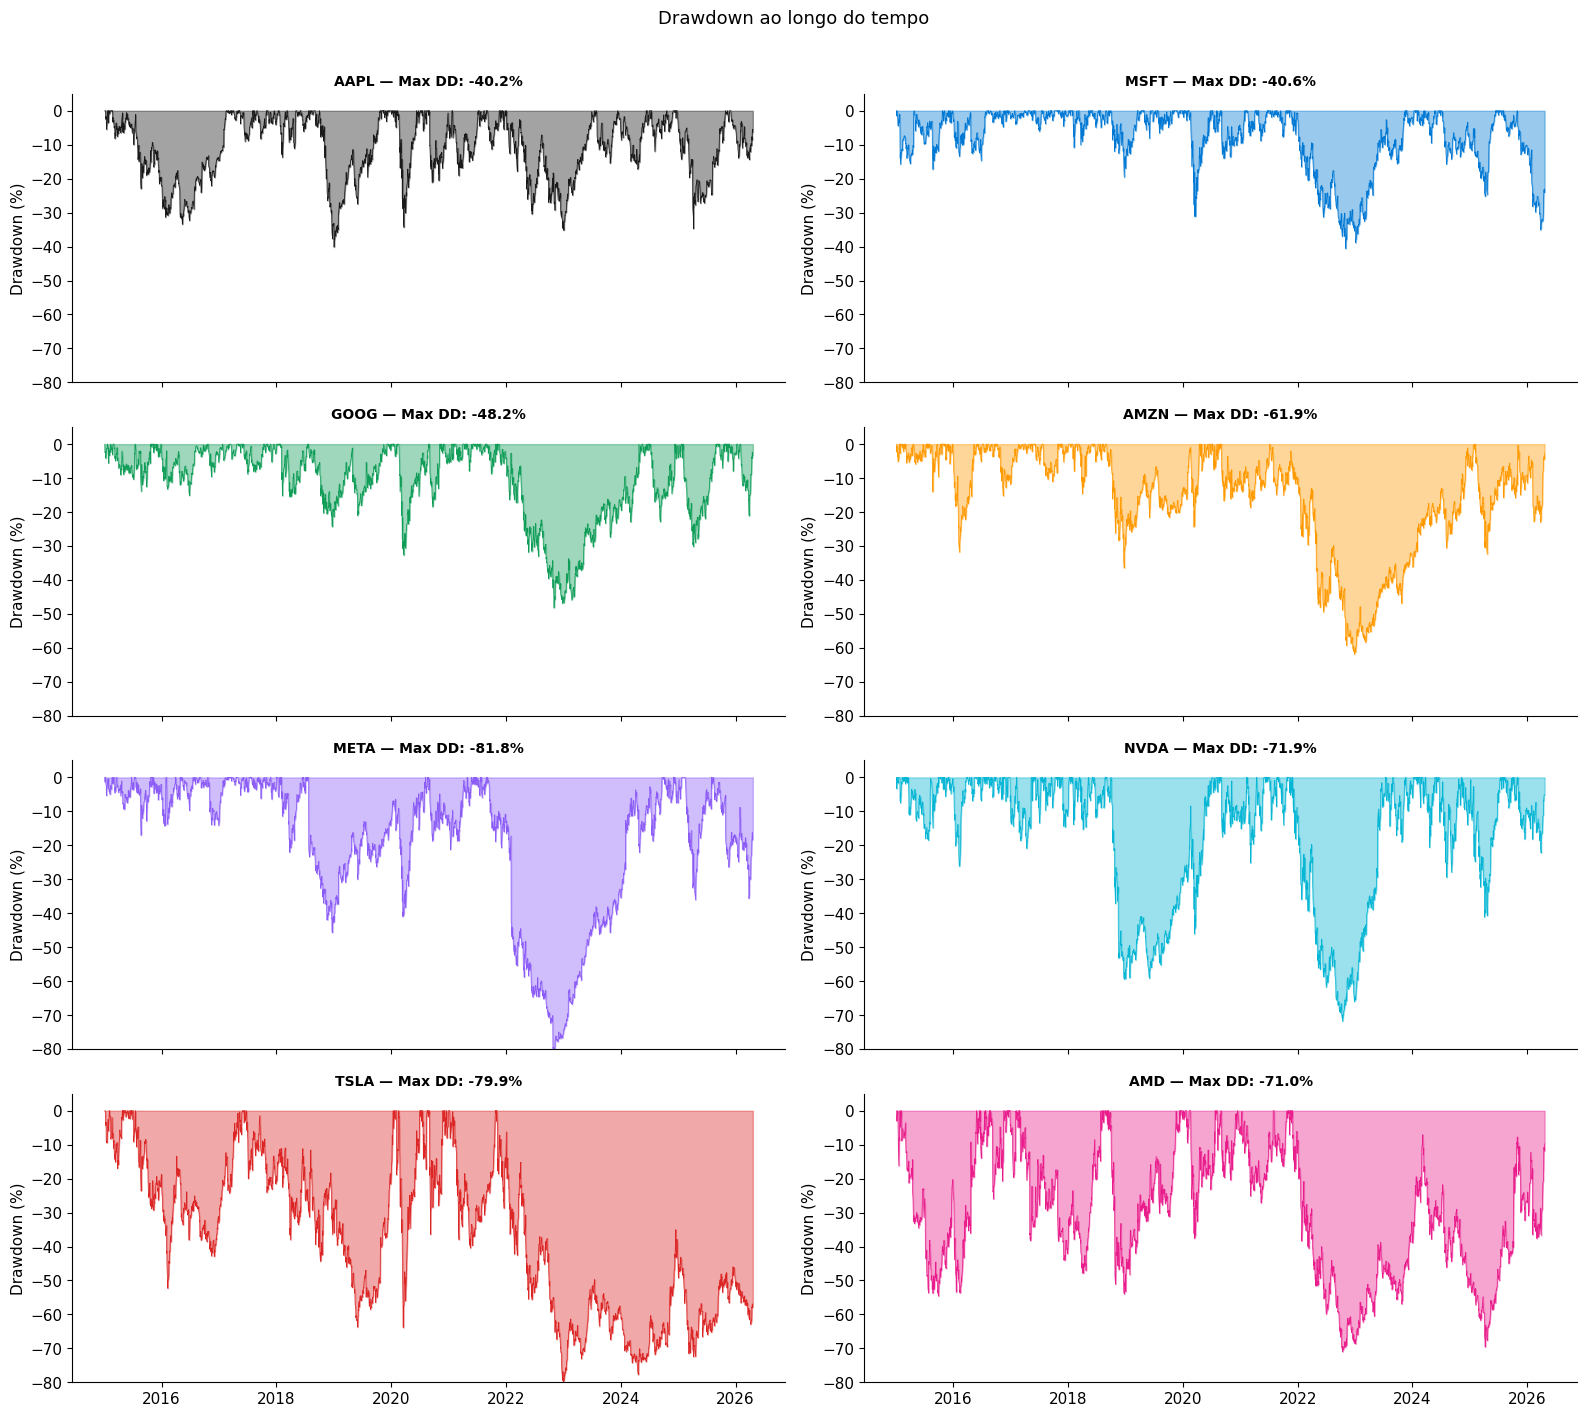

In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes = axes.flatten()

for ax, ticker in zip(axes, TICKERS):
    cum = (1 + log_returns[ticker]).cumprod()
    peak = cum.cummax()
    dd = (cum - peak) / peak
    
    ax.fill_between(dd.index, dd.values * 100, 0, color=COLORS[ticker], alpha=0.4)
    ax.plot(dd.index, dd.values * 100, color=COLORS[ticker], linewidth=0.5)
    ax.set_title(f'{ticker} — Max DD: {dd.min()*100:.1f}%', fontsize=10, fontweight='bold')
    ax.set_ylabel('Drawdown (%)')
    ax.set_ylim(-80, 5)
    ax.grid(axis='y', alpha=0.2)

plt.suptitle('Drawdown ao longo do tempo', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 3.4 Value at Risk — Paramétrico vs. Histórico

O VaR (Value at Risk) é uma técnica estatística que estima a perda máxima potencial de um investimento durante um período específico, dado um nível de confiança. Com 95% de confiança e horizonte de 1 dia, um VaR de -2.89% significa que a perda diária não deve ultrapassar 2.89% em condições normais de mercado.

O **VaR paramétrico** assume que os retornos seguem uma distribuição normal — só precisa da média e do desvio padrão. O **VaR histórico** não assume nenhuma distribuição — simplesmente encontra o percentil 5% dos retornos reais observados.

In [24]:
confidence = 0.05

# VaR Paramétrico (assume normalidade)
var_param = log_returns.mean() + stats.norm.ppf(confidence) * log_returns.std()

# VaR Histórico (percentil empírico)
var_hist = log_returns.quantile(confidence)

var_comparison = pd.DataFrame({
    'VaR Paramétrico (%)': (var_param * 100).round(3),
    'VaR Histórico (%)': (var_hist * 100).round(3),
    'Diferença (p.p.)': ((var_hist - var_param) * 100).round(3)
})

print("Value at Risk (95%) — Perda mínima nos 5% piores dias:")
var_comparison

Value at Risk (95%) — Perda mínima nos 5% piores dias:


,VaR Paramétrico (%),VaR Histórico (%),Diferença (p.p.)
Ticker,,,
AAPL,-2.890,-2.756,0.134
MSFT,-2.720,-2.664,0.057
GOOG,-2.882,-2.722,0.160
AMZN,-3.299,-3.110,0.190
META,-3.854,-3.372,0.481
NVDA,-4.766,-4.533,0.233
TSLA,-5.808,-5.312,0.496
AMD,-5.842,-5.443,0.399


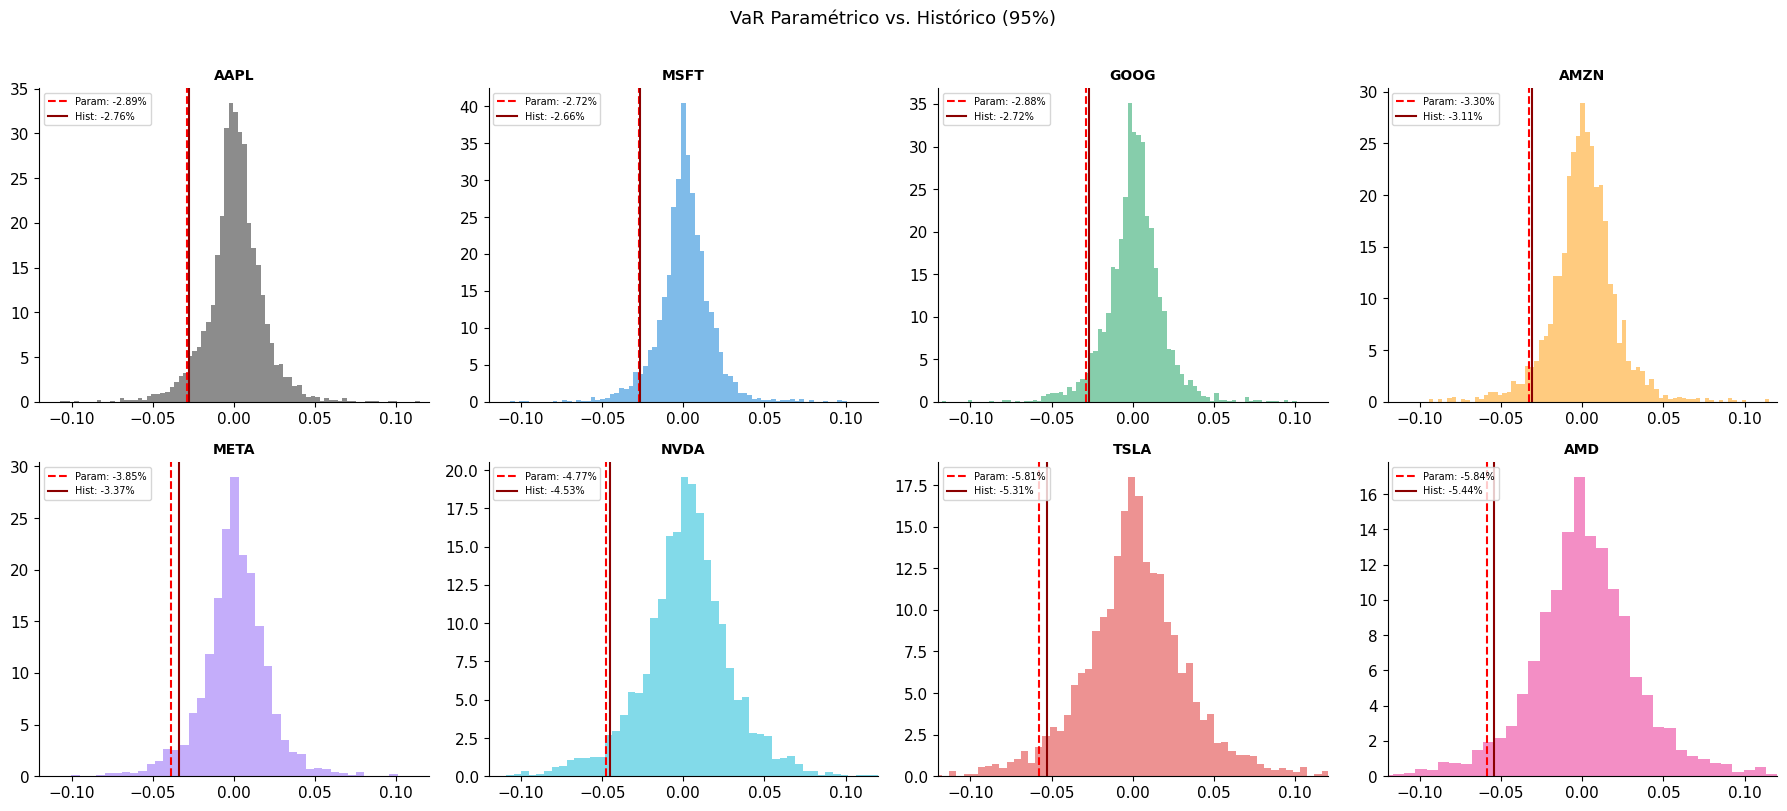

In [25]:
# Visualização: distribuição com linhas de VaR
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, ticker in zip(axes, TICKERS):
    data_r = log_returns[ticker].dropna()
    ax.hist(data_r, bins=100, density=True, alpha=0.5, color=COLORS[ticker], edgecolor='none')
    
    ax.axvline(var_param[ticker], color='red', linestyle='--', linewidth=1.5, label=f'Param: {var_param[ticker]*100:.2f}%')
    ax.axvline(var_hist[ticker], color='darkred', linestyle='-', linewidth=1.5, label=f'Hist: {var_hist[ticker]*100:.2f}%')
    
    ax.set_title(ticker, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlim(-0.12, 0.12)

plt.suptitle('VaR Paramétrico vs. Histórico (95%)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

### 3.5 Simulação de Monte Carlo (GBM)

O Geometric Brownian Motion (GBM) modela o preço como um processo com dois componentes: um drift (tendência constante) e um choque aleatório gaussiano escalado pela volatilidade. Repetindo isso milhares de vezes com choques diferentes, geramos cenários possíveis para o preço futuro.

Foram simulados 10.000 trajetórias para 252 dias (1 ano). A premissa central do GBM — volatilidade e drift constantes — é uma limitação que o regime-switching tenta corrigir.

In [26]:
def monte_carlo_gbm(last_price, mu, sigma, days=252, n_simulations=10000, seed=42):
    """Simula trajetórias de preço via GBM."""
    np.random.seed(seed)
    dt = 1 / 252
    drift = (mu - 0.5 * sigma**2) * dt
    diffusion = sigma * np.sqrt(dt)
    
    # Matriz de retornos simulados
    Z = np.random.standard_normal((days, n_simulations))
    log_returns_sim = drift + diffusion * Z
    
    # Trajetórias de preço
    price_paths = last_price * np.exp(np.cumsum(log_returns_sim, axis=0))
    price_paths = np.vstack([np.full(n_simulations, last_price), price_paths])
    
    return price_paths

# Simulação para NVDA (exemplo principal)
ticker_sim = 'NVDA'
mu_sim = log_returns[ticker_sim].mean() * 252
sigma_sim = log_returns[ticker_sim].std() * np.sqrt(252)
last_price_sim = prices[ticker_sim].iloc[-1]

paths = monte_carlo_gbm(last_price_sim, mu_sim, sigma_sim)
print(f"Simulação Monte Carlo para {ticker_sim}")
print(f"Último preço: ${last_price_sim:.2f}")
print(f"Drift anualizado: {mu_sim*100:.2f}%")
print(f"Volatilidade anualizada: {sigma_sim*100:.2f}%")
print(f"Trajetórias simuladas: {paths.shape[1]:,}")

Simulação Monte Carlo para NVDA
Último preço: $202.24
Drift anualizado: 53.57%
Volatilidade anualizada: 48.05%
Trajetórias simuladas: 10,000


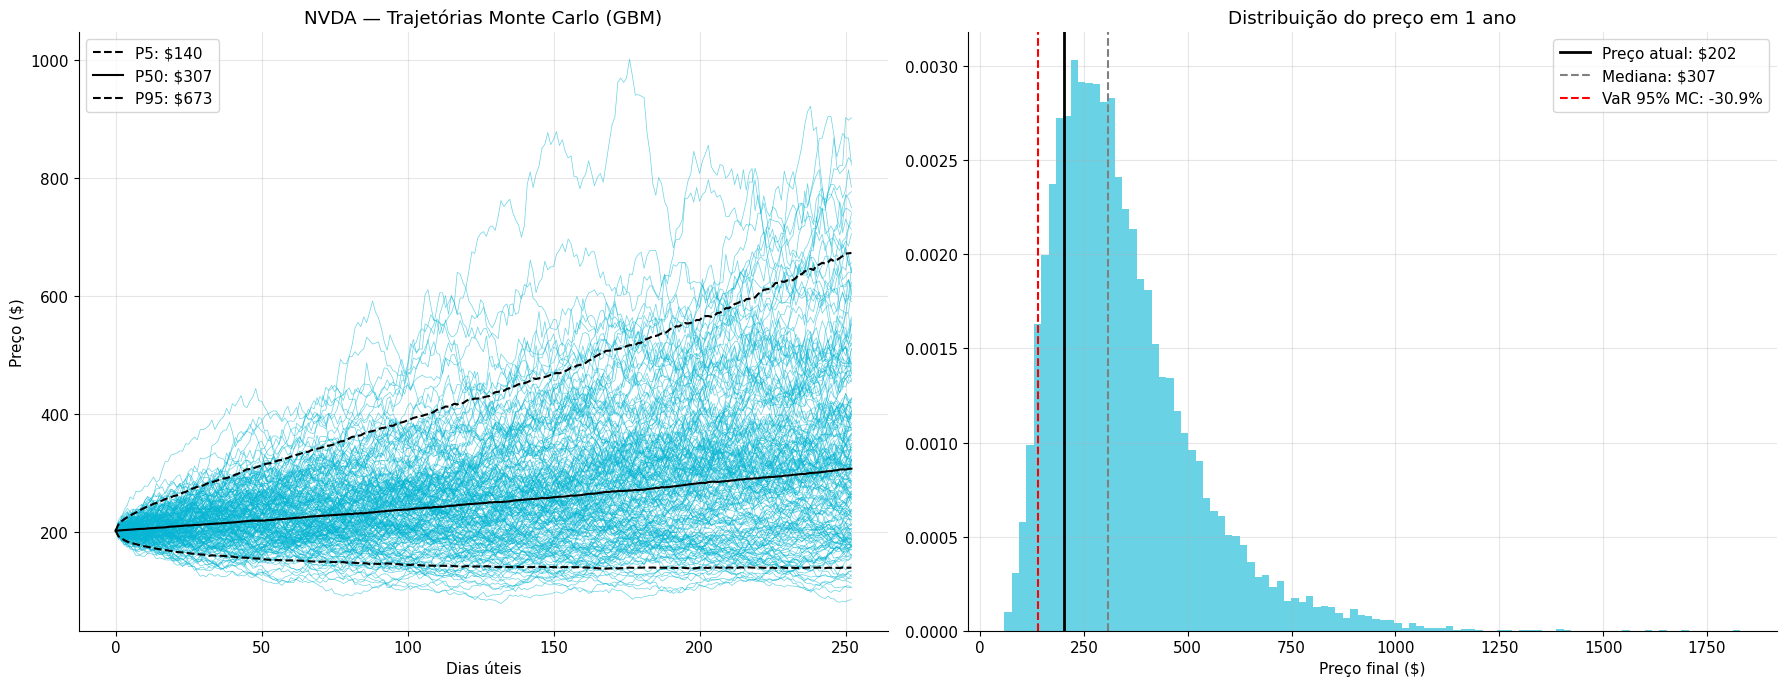

In [27]:
# Visualização das trajetórias
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Painel esquerdo: trajetórias individuais
ax = axes[0]
days_sim = np.arange(paths.shape[0])
for i in range(200):  # Mostrar 200 trajetórias
    ax.plot(days_sim, paths[:, i], color=COLORS[ticker_sim], alpha=0.6, linewidth=0.5)

# Percentis
for q, ls in [(5, '--'), (50, '-'), (95, '--')]:
    percentile = np.percentile(paths, q, axis=1)
    ax.plot(days_sim, percentile, color='black', linestyle=ls, linewidth=1.5,
            label=f'P{q}: ${percentile[-1]:.0f}')

ax.set_xlabel('Dias úteis')
ax.set_ylabel('Preço ($)')
ax.set_title(f'{ticker_sim} — Trajetórias Monte Carlo (GBM)')
ax.legend()
ax.grid(alpha=0.3)

# Painel direito: distribuição do preço final
ax = axes[1]
final_prices = paths[-1, :]
ax.hist(final_prices, bins=100, density=True, alpha=0.6, color=COLORS[ticker_sim], edgecolor='none')
ax.axvline(last_price_sim, color='black', linewidth=2, label=f'Preço atual: ${last_price_sim:.0f}')
ax.axvline(np.median(final_prices), color='gray', linestyle='--', linewidth=1.5,
           label=f'Mediana: ${np.median(final_prices):.0f}')

# VaR 95% via Monte Carlo
returns_sim = final_prices / last_price_sim - 1
var_mc = np.percentile(returns_sim, 5)
ax.axvline(last_price_sim * (1 + var_mc), color='red', linestyle='--', linewidth=1.5,
           label=f'VaR 95% MC: {var_mc*100:.1f}%')

ax.set_xlabel('Preço final ($)')
ax.set_title(f'Distribuição do preço em 1 ano')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 3.6 Monte Carlo com Regime-Switching

Usando os regimes identificados pelo HMM na análise exploratória, construímos um Monte Carlo que transita entre regimes de baixa e alta volatilidade segundo as probabilidades de transição estimadas, em vez de usar parâmetros fixos.

In [28]:
def monte_carlo_regime_switching(last_price, means, vols, trans_mat, 
                                  days=252, n_simulations=10000, seed=42):
    """Monte Carlo com regime-switching baseado em HMM."""
    np.random.seed(seed)
    
    prices_rs = np.zeros((days + 1, n_simulations))
    prices_rs[0] = last_price
    
    current_states = np.random.choice([0, 1], size=n_simulations, p=[0.7, 0.3])
    
    for t in range(1, days + 1):
        # Transição de estado
        rand_transition = np.random.random(n_simulations)
        for i in range(n_simulations):
            s = current_states[i]
            if rand_transition[i] > trans_mat[s, s]:
                current_states[i] = 1 - s
        
        # Gerar retornos conforme o regime atual
        Z = np.random.standard_normal(n_simulations)
        returns_t = np.where(
            current_states == 0,
            means[0] + vols[0] * Z,
            means[1] + vols[1] * Z
        )
        
        prices_rs[t] = prices_rs[t-1] * np.exp(returns_t)
    
    return prices_rs

# Simulação regime-switching
paths_rs = monte_carlo_regime_switching(last_price_sim, means, vols, trans_mat)

# Simulação GBM padrão para comparação
paths_gbm = monte_carlo_gbm(last_price_sim, mu_sim, sigma_sim)

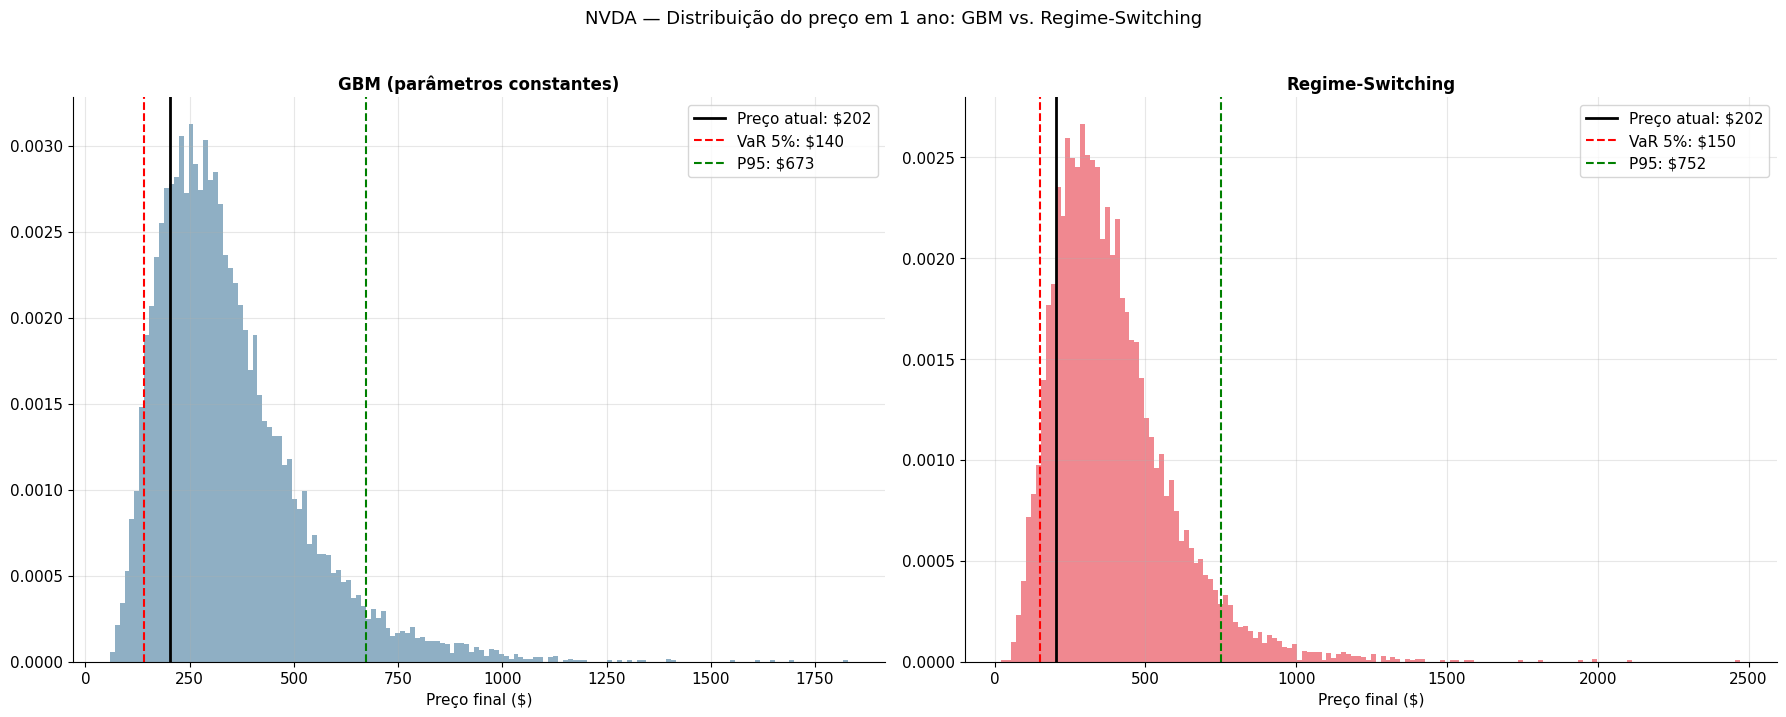

Métrica                                    GBM   Regime-Switch
------------------------------------------------------------
Mediana ($)                                307             350
Média ($)                                  344             389
Desvio padrão ($)                          173             198
P5 ($)                                     140             150
P95 ($)                                    673             752

VaR 95% (retorno %)                     -30.9%          -25.8%


In [29]:
# Comparação das distribuições de preço final
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, p, title, color in zip(axes, 
    [paths_gbm[-1,:], paths_rs[-1,:]],
    ['GBM (parâmetros constantes)', 'Regime-Switching'],
    ['#457B9D', '#E63946']):
    
    ax.hist(p, bins=150, density=True, alpha=0.6, color=color, edgecolor='none')
    ax.axvline(last_price_sim, color='black', linewidth=2, label=f'Preço atual: ${last_price_sim:.0f}')
    ax.axvline(np.percentile(p, 5), color='red', linestyle='--', linewidth=1.5,
               label=f'VaR 5%: ${np.percentile(p, 5):.0f}')
    ax.axvline(np.percentile(p, 95), color='green', linestyle='--', linewidth=1.5,
               label=f'P95: ${np.percentile(p, 95):.0f}')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Preço final ($)')
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle(f'{ticker_sim} — Distribuição do preço em 1 ano: GBM vs. Regime-Switching', 
             y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

# Estatísticas comparativas
print(f"{'Métrica':<30} {'GBM':>15} {'Regime-Switch':>15}")
print("-" * 60)
for label, func in [('Mediana ($)', np.median), ('Média ($)', np.mean),
                     ('Desvio padrão ($)', np.std),
                     ('P5 ($)', lambda x: np.percentile(x, 5)),
                     ('P95 ($)', lambda x: np.percentile(x, 95))]:
    print(f"{label:<30} {func(paths_gbm[-1,:]):>15.0f} {func(paths_rs[-1,:]):>15.0f}")

ret_gbm = paths_gbm[-1,:] / last_price_sim - 1
ret_rs = paths_rs[-1,:] / last_price_sim - 1
print(f"\n{'VaR 95% (retorno %)':<30} {np.percentile(ret_gbm, 5)*100:>14.1f}% {np.percentile(ret_rs, 5)*100:>14.1f}%")

O regime-switching gera distribuições com maior dispersão nos dois sentidos, isto é, a incerteza é maior tanto para cenários negativos quanto positivos. Isso reflete a realidade de que o mercado pode transitar para um regime de alta volatilidade a qualquer momento.

### 3.7 Comparação consolidada de VaR

Ao longo do projeto, calculamos o Value at Risk por quatro métodos distintos, cada um com premissas diferentes. Para possibilitar a comparação entre esses diferentes cálculos, todos foram colocados no mesmo horizonte (1 dia)

In [30]:
# VaR consolidado para todos os ativos — 4 métodos

# 1. Paramétrico (já calculado)
# 2. Histórico (já calculado)

# 3. Monte Carlo GBM (1 dia)
var_mc_all = {}
for ticker in TICKERS:
    mu_t = log_returns[ticker].mean() * 252
    sigma_t = log_returns[ticker].std() * np.sqrt(252)
    
    np.random.seed(42)
    dt = 1/252
    Z = np.random.standard_normal(100000)
    sim_returns_1d = (mu_t - 0.5 * sigma_t**2) * dt + sigma_t * np.sqrt(dt) * Z
    var_mc_all[ticker] = np.percentile(sim_returns_1d, 5)

var_mc_series = pd.Series(var_mc_all)

# 4. Monte Carlo Regime-Switching (1 dia) — usando parâmetros do HMM da NVDA como proxy
# Para uma comparação justa, treinamos HMM para cada ativo
var_rs_all = {}
for ticker in TICKERS:
    try:
        ret_t = log_returns[ticker].dropna().values.reshape(-1, 1)
        hmm_t = GaussianHMM(n_components=2, covariance_type='full', n_iter=200, random_state=42)
        hmm_t.fit(ret_t)
        
        # Identificar regimes
        if hmm_t.covars_[0][0][0] > hmm_t.covars_[1][0][0]:
            m = [hmm_t.means_[1][0], hmm_t.means_[0][0]]
            v = [np.sqrt(hmm_t.covars_[1][0][0]), np.sqrt(hmm_t.covars_[0][0][0])]
            tm = hmm_t.transmat_[[1,0]][:,[1,0]]
        else:
            m = [hmm_t.means_[0][0], hmm_t.means_[1][0]]
            v = [np.sqrt(hmm_t.covars_[0][0][0]), np.sqrt(hmm_t.covars_[1][0][0])]
            tm = hmm_t.transmat_
        
        # Simular 1 dia com regime-switching
        np.random.seed(42)
        n_sim = 100000
        states = np.random.choice([0, 1], size=n_sim, p=[0.7, 0.3])
        Z = np.random.standard_normal(n_sim)
        sim_ret = np.where(states == 0, m[0] + v[0] * Z, m[1] + v[1] * Z)
        var_rs_all[ticker] = np.percentile(sim_ret, 5)
    except:
        var_rs_all[ticker] = np.nan

var_rs_series = pd.Series(var_rs_all)

# Tabela comparativa
var_consolidated = pd.DataFrame({
    'Paramétrico (%)': (var_param * 100).round(3),
    'Histórico (%)': (var_hist * 100).round(3),
    'MC GBM (%)': (var_mc_series * 100).round(3),
    'MC Regime-Switch (%)': (var_rs_series * 100).round(3)
})

print("Comparação consolidada de VaR (95%, 1 dia):")
print("=" * 70)
var_consolidated

Comparação consolidada de VaR (95%, 1 dia):


,Paramétrico (%),Histórico (%),MC GBM (%),MC Regime-Switch (%)
AAPL,-2.890,-2.756,-2.904,-3.121
MSFT,-2.720,-2.664,-2.732,-3.055
GOOG,-2.882,-2.722,-2.896,-3.154
AMZN,-3.299,-3.110,-3.318,-3.356
META,-3.854,-3.372,-3.879,-4.760
NVDA,-4.766,-4.533,-4.808,-4.747
TSLA,-5.808,-5.312,-5.868,-5.652
AMD,-5.842,-5.443,-5.903,-6.286


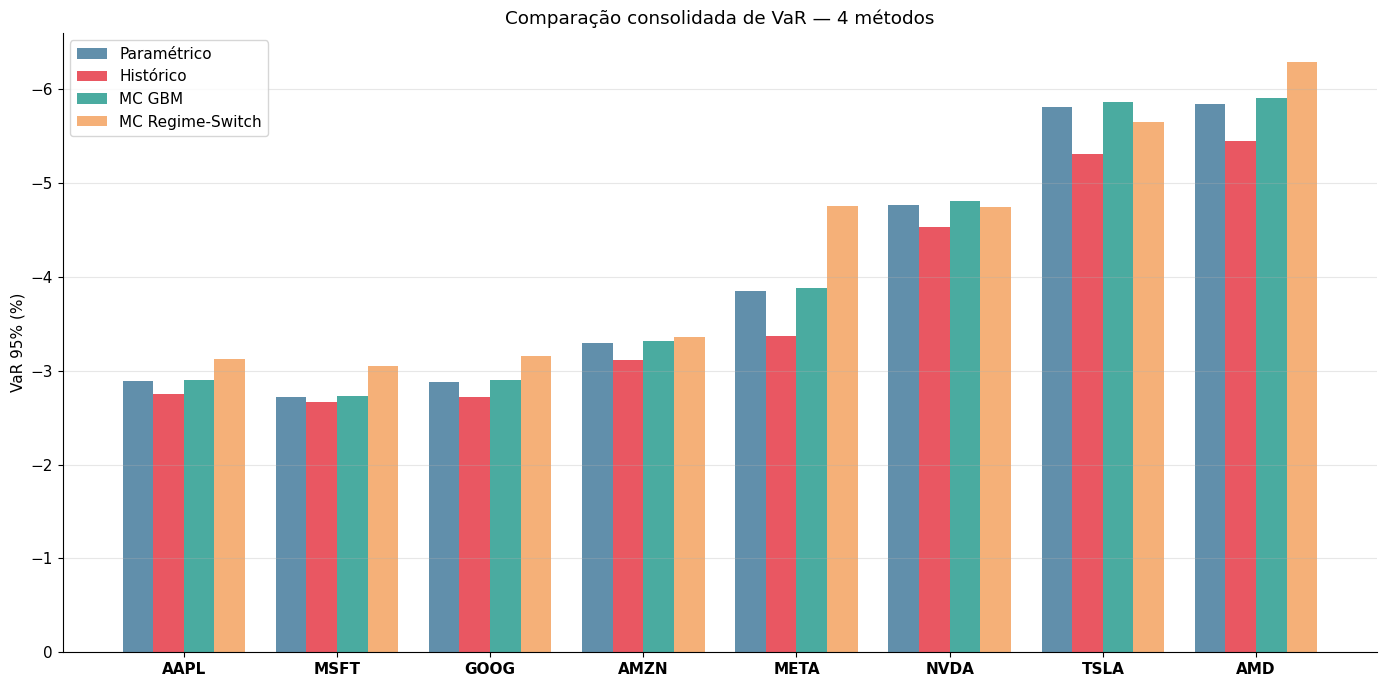

In [31]:
# Visualização consolidada — 4 métodos
fig, ax = plt.subplots(figsize=(14, 7))

x = np.arange(len(TICKERS))
width = 0.2

bars1 = ax.bar(x - 1.5*width, var_param[TICKERS].values * 100, width, 
               label='Paramétrico', color='#457B9D', alpha=0.85)
bars2 = ax.bar(x - 0.5*width, var_hist[TICKERS].values * 100, width, 
               label='Histórico', color='#E63946', alpha=0.85)
bars3 = ax.bar(x + 0.5*width, var_mc_series[TICKERS].values * 100, width, 
               label='MC GBM', color='#2A9D8F', alpha=0.85)
bars4 = ax.bar(x + 1.5*width, var_rs_series[TICKERS].values * 100, width, 
               label='MC Regime-Switch', color='#F4A261', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(TICKERS, fontweight='bold')
ax.set_ylabel('VaR 95% (%)')
ax.set_title('Comparação consolidada de VaR — 4 métodos')
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

O VaR paramétrico e o Monte Carlo com GBM produzem resultados similares, pois ambos assumem normalidade. O VaR histórico reflete os eventos reais observados. O regime-switching tende a produzir estimativas mais conservadoras para ações com mudanças de regime pronunciadas, capturando a possibilidade de transição para um estado de alta volatilidade.

---

## 4. Exercício de Previsão

Esta seção é um **exercício** — não uma tentativa séria de construir um sistema de trading. O objetivo é demonstrar empiricamente as limitações da previsão de retornos de ações individuais utilizando histórico de preços e entender por que essas limitações existem.

### 4.1 Modelo ingênuo: retornos defasados

A primeira abordagem é a mais simples: usar retornos defasados (lags) para prever o retorno de hoje. Foram testados múltiplos lags para verificar se informação mais distante no tempo acrescenta algo.

In [ ]:
# Modelo com múltiplos lags — Regressão Linear
ticker_pred = 'NVDA'
returns_pred = log_returns[ticker_pred].dropna()

tscv = TimeSeriesSplit(n_splits=5)

print(f"Modelos ingênuos para {ticker_pred} — Regressão Linear com lags")
print(f"{'Modelo':<30} {'R² médio':>12}")
print("-" * 42)

lag_results = {}
for n_lags in [1, 2, 3, 5, 10, 20]:
    # Construir features de lag
    df_lags = pd.DataFrame()
    for lag in range(1, n_lags + 1):
        df_lags[f'lag_{lag}'] = returns_pred.shift(lag)
    df_lags['target'] = returns_pred
    df_lags.dropna(inplace=True)
    
    X = df_lags.drop('target', axis=1).values
    y = df_lags['target'].values
    
    r2_list = []
    for train_idx, test_idx in tscv.split(X):
        lr = LinearRegression()
        lr.fit(X[train_idx], y[train_idx])
        y_pred = lr.predict(X[test_idx])
        r2_list.append(r2_score(y[test_idx], y_pred))
    
    mean_r2 = np.mean(r2_list)
    lag_results[n_lags] = mean_r2
    print(f"{'Regressão (' + str(n_lags) + ' lag' + ('s' if n_lags > 1 else '') + ')':<30} {mean_r2:>12.6f}")

Modelos ingênuos para NVDA — Regressão Linear com lags
Modelo                             R² médio
------------------------------------------
Regressão (1 lag)                 -0.000176
Regressão (2 lags)                -0.000796
Regressão (3 lags)                -0.002732
Regressão (5 lags)                -0.005066
Regressão (10 lags)               -0.008696
Regressão (20 lags)               -0.014634

Adicionar mais lags não melhora o modelo — o R² permanece próximo de zero.
Retornos passados não contêm informação preditiva sobre retornos futuros.


Note que adicionar mais lags não melhora o modelo (na verdade tem uma piora marginal) uma vez que o R² continúa negativo. Com isso, observa-se que retornos passados sem nenhum tipo de tratamento não possuem informação preditiva sobre retornos futuros.

### 4.2 Random Forest com lags

Também foi testado se um modelo mais complexo (Random Forest) consegue extrair informação dos mesmos lags que a regressão linear não consegue.

In [ ]:
# Random Forest com múltiplos lags
print(f"Random Forest com lags para {ticker_pred}")
print(f"{'Modelo':<30} {'R² médio':>12}")
print("-" * 42)

for n_lags in [5, 10, 20]:
    df_lags = pd.DataFrame()
    for lag in range(1, n_lags + 1):
        df_lags[f'lag_{lag}'] = returns_pred.shift(lag)
    df_lags['target'] = returns_pred
    df_lags.dropna(inplace=True)
    
    X = df_lags.drop('target', axis=1).values
    y = df_lags['target'].values
    
    r2_list = []
    for train_idx, test_idx in tscv.split(X):
        rf = RandomForestRegressor(n_estimators=200, max_depth=5, 
                                    min_samples_leaf=20, random_state=42)
        rf.fit(X[train_idx], y[train_idx])
        y_pred = rf.predict(X[test_idx])
        r2_list.append(r2_score(y[test_idx], y_pred))
    
    print(f"{'RF (' + str(n_lags) + ' lags)':<30} {np.mean(r2_list):>12.6f}")

Random Forest com lags para NVDA
Modelo                             R² médio
------------------------------------------
RF (5 lags)                       -0.014282
RF (10 lags)                      -0.004768
RF (20 lags)                      -0.004373

Mesmo com um modelo mais flexível, lags sozinhos não produzem poder preditivo.
O problema não é o modelo — é a ausência de sinal nos dados brutos.


Mesmo com um modelo mais flexível, lags sozinhos não produzem poder preditivo. O problema não é o modelo e sim a ausência de sinal nos dados brutos.

### 4.3 Feature Engineering

O preço cru não contém informação preditiva. Construímos features derivadas a partir dos mesmos dados do yfinance — momentum, volatilidade realizada, volume relativo, distância da média móvel, RSI e retornos defasados — para verificar se extraem algum sinal adicional.

In [34]:
def build_features(prices_df, returns_df, volume_df, ticker):
    """Constrói features derivadas para um ativo."""
    df = pd.DataFrame(index=returns_df.index)
    
    ret = returns_df[ticker]
    price = prices_df[ticker]
    
    # Retornos defasados
    for lag in [1, 2, 3, 5, 10]:
        df[f'ret_lag_{lag}'] = ret.shift(lag)
    
    # Momentum (retorno acumulado)
    for window in [5, 10, 20]:
        df[f'momentum_{window}'] = ret.rolling(window).sum()
    
    # Volatilidade realizada
    for window in [5, 10, 20]:
        df[f'vol_realized_{window}'] = ret.rolling(window).std()
    
    # Distância da SMA
    for window in [20, 50]:
        sma = price.rolling(window).mean()
        df[f'dist_sma_{window}'] = (price - sma) / sma
    
    # RSI (14 períodos)
    delta = price.diff()
    gain = delta.where(delta > 0, 0).rolling(14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
    rs = gain / loss
    df['rsi_14'] = 100 - (100 / (1 + rs))
    
    # Volume relativo (se disponível)
    if volume_df is not None and ticker in volume_df.columns:
        vol = volume_df[ticker]
        df['volume_ratio'] = vol / vol.rolling(20).mean()
    
    # Target: retorno do próximo dia
    df['target'] = ret.shift(-1)
    
    return df.dropna()

features_df = build_features(prices, log_returns, volume, ticker_pred)

print(f"Features construídas: {features_df.shape[1] - 1}")
print(f"Observações: {features_df.shape[0]}")
print(f"\nFeatures:")
for col in features_df.columns[:-1]:
    print(f"  - {col}")

Features construídas: 15
Observações: 2791

Features:
  - ret_lag_1
  - ret_lag_2
  - ret_lag_3
  - ret_lag_5
  - ret_lag_10
  - momentum_5
  - momentum_10
  - momentum_20
  - vol_realized_5
  - vol_realized_10
  - vol_realized_20
  - dist_sma_20
  - dist_sma_50
  - rsi_14
  - volume_ratio


In [ ]:
# Modelo com features — Regressão Linear e Random Forest
X_feat = features_df.drop('target', axis=1).values
y_feat = features_df['target'].values
feature_names = features_df.drop('target', axis=1).columns.tolist()

tscv = TimeSeriesSplit(n_splits=5)

results = {}
for name, model in [('Linear Regression', LinearRegression()),
                     ('Random Forest', RandomForestRegressor(n_estimators=200, max_depth=5, 
                                                              min_samples_leaf=20, random_state=42))]:
    r2_list = []
    rmse_list = []
    
    for train_idx, test_idx in tscv.split(X_feat):
        X_train, X_test = X_feat[train_idx], X_feat[test_idx]
        y_train, y_test = y_feat[train_idx], y_feat[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        
        r2_list.append(r2_score(y_test, y_pred))
        rmse_list.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    
    results[name] = {'R²': np.mean(r2_list), 'RMSE': np.mean(rmse_list)}

print(f"Resultados — Previsão de retorno diário para {ticker_pred}")
print(f"{'Modelo':<35} {'R² médio':>12} {'RMSE médio':>12}")
print("-" * 60)
print(f"{'Ingênuo (1 lag, Reg. Linear)':<35} {lag_results[1]:>12.6f} {'—':>12}")
print(f"{'Ingênuo (20 lags, Reg. Linear)':<35} {lag_results[20]:>12.6f} {'—':>12}")
for name, res in results.items():
    print(f"{name + ' (c/ features)':<35} {res['R²']:>12.6f} {res['RMSE']:>12.6f}")

Resultados — Previsão de retorno diário para NVDA
Modelo                                  R² médio   RMSE médio
------------------------------------------------------------
Ingênuo (1 lag, Reg. Linear)           -0.000176            —
Ingênuo (20 lags, Reg. Linear)         -0.014634            —
Linear Regression (c/ features)        -0.017684     0.031543
Random Forest (c/ features)            -0.014522     0.031478


### 4.4 Interpretação

A progressão dos resultados é clara:

1. **Lags sozinhos com regressão linear** — R² negativo e próximo de zero. Retornos passados não explicam retornos futuros.
2. **Lags sozinhos com Random Forest** — R² negativo e igualmente próximo de zero. O problema não é a complexidade do modelo, é a ausência de sinal.
3. **Features derivadas** — R² também negativo e também próximo de zero.

Isso não é uma falha do modelo, é uma propriedade fundamental dos mercados financeiros. Em mercados líquidos como big techs, a informação é incorporada rapidamente aos preços (eficiência de mercado). O sinal, se existir, é minúsculo em relação ao ruído. E as próprias previsões, se amplamente adotadas, alterariam o comportamento que tentam prever (reflexividade). O valor deste exercício está em demonstrar sistematicamente por que o R² é baixo e o que isso revela sobre a natureza dos mercados.

---

## 5. Conclusão

### Síntese dos achados

Este projeto investigou ações de big techs e semicondutores sob múltiplas perspectivas. Os principais achados foram:

1. **Retornos não são normais.** As distribuições apresentam caudas pesadas e clustering de volatilidade, invalidando a premissa de normalidade usada em métricas como o VaR paramétrico.

2. **Correlação não é constante.** A rolling correlation revelou que a co-movimentação entre big techs oscila ao longo do tempo, disparando em crises (como a COVID) e podendo diminuir quando uma empresa se descola do grupo por magnitude de crescimento, como no caso da NVDA.

3. **Dependência nas caudas é assimétrica.** Em todos os pares testados, ações caem juntas com mais intensidade do que sobem juntas. A diversificação entre big techs funciona nos dias bons mas falha parcialmente nos dias ruins.

4. **O mercado opera em regimes.** O HMM identificou estados latentes com parâmetros estatísticos distintos. O Monte Carlo com regime-switching produz distribuições com caudas mais realistas e maior incerteza nos dois sentidos.

5. **Poucos fatores dominam a movimentação.** O PCA mostrou que um único fator (mercado) explica mais de metade da variância, e o gráfico de loadings revelou dois subgrupos naturais: semicondutores/alto crescimento vs. big tech madura.

6. **Previsibilidade de retornos é fundamentalmente limitada.** Nem mais lags, nem modelos mais complexos, nem features derivadas produzem poder preditivo significativo, o que é consistente com a teoria de mercados eficientes e a baixa razão sinal-ruído.

### Limitações

- Os parâmetros do HMM são estimados in-sample e podem ser instáveis com poucas transições de regime.
- O Monte Carlo assume que os parâmetros passados são representativos do futuro.
- A análise de copulas é empírica.
- O escopo é limitado a big techs, generalizar para outros setores exigiria validação adicional.
- Volatilidade é usada como proxy de risco por convenção, mas não captura todas as dimensões de risco relevantes.